# 🏏 IPL Smart Analytics System
## Win Probability Prediction & Optimal Team Builder using IPL Ball-by-Ball Dataset (2008–2025)

---

**Course:** MSc Applied Statistics / Data Science  
**Dataset:** IPL Ball-by-Ball Data (2008–2025)  
**File Used:** `ipl_ball_by_ball.csv`  
**Tools:** Python, Pandas, NumPy, Scikit-learn, XGBoost, Matplotlib, Seaborn, Plotly

---

## 📋 Project Abstract

The Indian Premier League (IPL) is one of the world's most data-rich sporting competitions. This project applies machine learning and statistical analysis to a ball-by-ball dataset spanning 2008 to 2025 to achieve three goals:

1. **Win Probability Prediction** — Build a real-time model that predicts match outcome probabilities during a second-innings chase.
2. **Smart Team Builder** — Use historical player performance metrics to recommend an optimal squad for a new IPL franchise.
3. **Statistical Analysis** — Apply hypothesis testing and exploratory analysis to uncover patterns in toss advantage, venue effects, and player consistency.

---

## 📑 Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load & Inspect Dataset](#2-load-dataset)
3. [Data Cleaning](#3-data-cleaning)
4. [Exploratory Data Analysis (EDA)](#4-eda)
5. [Feature Engineering](#5-feature-engineering)
6. [Module 1 — Win Probability ML Model](#6-module1)
7. [Module 2 — Smart Team Builder](#7-module2)
8. [Module 3 — Statistical Analysis](#8-module3)
9. [Dashboard Visualizations](#9-dashboard)
10. [Results & Insights](#10-results)
11. [Conclusion](#11-conclusion)
12. [Future Scope](#12-future-scope)

---
## 1. Import Libraries
<a id='1-import-libraries'></a>

In [31]:
# ============================================================
# CELL 1 — LIBRARY IMPORTS
# We import all required libraries at the top.
# If xgboost is not installed, we catch the error and fall back
# to using only Logistic Regression + Random Forest.
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Core data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Plotly for interactive charts
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
    print("✅ Plotly available — interactive charts enabled")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("⚠️  Plotly not found — using matplotlib/seaborn only")

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# XGBoost (optional)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not found — will skip XGBoost model")

# Statistical tests
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, shapiro

# Miscellaneous
import re
from collections import Counter

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)
RANDOM_STATE = 42

print("\n✅ All libraries imported successfully!")

✅ Plotly available — interactive charts enabled
✅ XGBoost available

✅ All libraries imported successfully!


---
## 2. Load & Inspect Dataset
<a id='2-load-dataset'></a>

We first load the raw CSV, print shape and column names, then look at a few rows.
This helps us understand the structure **before** we clean anything.

In [32]:
# ============================================================
# CELL 2 — LOAD DATASET
# ============================================================

# Load the ball-by-ball CSV
df_raw = pd.read_csv('/content/IPL.csv')

print("=" * 60)
print(f"Dataset Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("=" * 60)

print("\n📋 Column Names:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:>2}. {col}  ({df_raw[col].dtype})")

print("\n📌 First 5 rows:")
df_raw.head()

Dataset Shape : 278,205 rows × 64 columns

📋 Column Names:
   1. Unnamed: 0  (int64)
   2. match_id  (int64)
   3. date  (object)
   4. match_type  (object)
   5. event_name  (object)
   6. innings  (int64)
   7. batting_team  (object)
   8. bowling_team  (object)
   9. over  (int64)
  10. ball  (int64)
  11. ball_no  (float64)
  12. batter  (object)
  13. bat_pos  (int64)
  14. runs_batter  (int64)
  15. balls_faced  (int64)
  16. bowler  (object)
  17. valid_ball  (int64)
  18. runs_extras  (int64)
  19. runs_total  (int64)
  20. runs_bowler  (int64)
  21. runs_not_boundary  (bool)
  22. extra_type  (object)
  23. non_striker  (object)
  24. non_striker_pos  (int64)
  25. wicket_kind  (object)
  26. player_out  (object)
  27. fielders  (object)
  28. runs_target  (float64)
  29. review_batter  (object)
  30. team_reviewed  (object)
  31. review_decision  (object)
  32. umpire  (object)
  33. umpires_call  (bool)
  34. player_of_match  (object)
  35. match_won_by  (object)
  36. win_o

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [33]:
# ============================================================
# CELL 3 — BASIC STATISTICS & MISSING VALUE AUDIT
# ============================================================

print("📊 Basic Info:")
df_raw.info()

print("\n📊 Descriptive Statistics (numeric columns):")
display(df_raw.describe())

# Missing value check
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("\n✅ No missing values found!")
else:
    print("\n⚠️  Missing Values:")
    display(missing_df)

📊 Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278205 entries, 0 to 278204
Data columns (total 64 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         278205 non-null  int64  
 1   match_id           278205 non-null  int64  
 2   date               278205 non-null  object 
 3   match_type         278205 non-null  object 
 4   event_name         278205 non-null  object 
 5   innings            278205 non-null  int64  
 6   batting_team       278205 non-null  object 
 7   bowling_team       278205 non-null  object 
 8   over               278205 non-null  int64  
 9   ball               278205 non-null  int64  
 10  ball_no            278205 non-null  float64
 11  batter             278205 non-null  object 
 12  bat_pos            278205 non-null  int64  
 13  runs_batter        278205 non-null  int64  
 14  balls_faced        278205 non-null  int64  
 15  bowler             278205 non-null  o

,Unnamed: 0,match_id,innings,over,ball,ball_no,bat_pos,runs_batter,balls_faced,valid_ball,...,month,year,balls_per_over,overs,team_runs,team_balls,team_wicket,batter_runs,batter_balls,bowler_wicket
count,278205.000000,2.782050e+05,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,...,278205.000000,278205.000000,278205.0,278205.0,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000,278205.000000
mean,139102.000000,9.422687e+05,1.482914,9.193839,3.488855,9.542725,3.612555,1.277378,0.967362,0.963182,...,4.787933,2016.710178,6.0,20.0,77.110498,58.614637,2.456972,18.327424,14.011211,0.045470
std,80311.010157,3.817198e+05,0.502571,5.681511,1.708263,5.682938,2.168978,1.651107,0.177687,0.188315,...,1.586724,5.248572,0.0,0.0,49.957873,34.117619,2.100374,18.578093,11.833930,0.208333
min,0.000000,3.359820e+05,1.000000,0.000000,1.000000,0.100000,1.000000,0.000000,0.000000,0.000000,...,3.000000,2008.000000,6.0,20.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,69551.000000,5.483530e+05,1.000000,4.000000,2.000000,4.500000,2.000000,0.000000,1.000000,1.000000,...,4.000000,2012.000000,6.0,20.0,36.000000,29.000000,1.000000,4.000000,5.000000,0.000000
50%,139102.000000,1.082601e+06,1.000000,9.000000,3.000000,9.400000,3.000000,1.000000,1.000000,1.000000,...,4.000000,2017.000000,6.0,20.0,73.000000,58.000000,2.000000,12.000000,11.000000,0.000000
75%,208653.000000,1.304049e+06,2.000000,14.000000,5.000000,14.400000,5.000000,1.000000,1.000000,1.000000,...,5.000000,2022.000000,6.0,20.0,113.000000,88.000000,4.000000,27.000000,20.000000,0.000000
max,278204.000000,1.485779e+06,6.000000,19.000000,7.000000,19.600000,11.000000,6.000000,1.000000,1.000000,...,11.000000,2025.000000,6.0,20.0,287.000000,121.000000,10.000000,175.000000,73.000000,1.000000



⚠️  Missing Values:


,Missing Count,Missing %
team_reviewed,277333,99.69
review_batter,277333,99.69
review_decision,277333,99.69
umpire,277333,99.69
superover_winner,274309,98.60
method,274315,98.60
result_type,273503,98.31
fielders,268192,96.40
new_batter,264884,95.21
next_batter,264884,95.21


In [34]:
# ============================================================
# CELL 4 — SMART COLUMN NAME DETECTOR
# Different Kaggle versions use slightly different column names.
# This cell normalises them to a standard set used throughout.
# ============================================================

# Normalise all column names: lowercase + replace spaces/hyphens with underscore
df_raw.columns = [
    col.strip().lower()
       .replace(' ', '_')
       .replace('-', '_')
       .replace('/', '_')
    for col in df_raw.columns
]

print("Normalised columns:")
print(list(df_raw.columns))

# ── Column alias mapping ─────────────────────────────────────
# We try to map common column name variants to our standard names.
ALIAS = {
    # match identifier
    'match_id':          ['id', 'match_id', 'matchid'],
    # season / year
    'season':            ['season', 'year', 'ipl_year'],
    # innings number
    'innings':           ['innings', 'inning', 'innings_no', 'innings_number'],
    # over number
    'over':              ['over', 'over_no', 'over_number', 'overs'],
    # ball within over
    'ball':              ['ball', 'ball_number', 'delivery'],
    # batting team
    'batting_team':      ['batting_team', 'bat_team', 'team_batting'],
    # bowling team
    'bowling_team':      ['bowling_team', 'bowl_team', 'team_bowling'],
    # batter name
    'batter':            ['batter', 'batsman', 'striker', 'batting_player'],
    # bowler name
    'bowler':            ['bowler', 'bowling_player'],
    # non-striker
    'non_striker':       ['non_striker', 'non_striking_batsman'],
    # runs scored off bat
    'batsman_runs':      ['batsman_runs', 'runs_off_bat', 'batter_runs', 'runs'],
    # extras
    'extra_runs':        ['extra_runs', 'extras', 'extra'],
    # total runs on that delivery
    'total_runs':        ['total_runs', 'runs_total', 'total'],
    # wicket details
    'is_wicket':         ['is_wicket', 'wicket', 'player_dismissed_bool'],
    'player_dismissed':  ['player_dismissed', 'dismissed_player', 'wicket_player'],
    'dismissal_kind':    ['dismissal_kind', 'kind', 'wicket_type', 'method'],
    # venue
    'venue':             ['venue', 'ground', 'stadium', 'city'],
    # toss
    'toss_winner':       ['toss_winner', 'toss_won_by'],
    'toss_decision':     ['toss_decision', 'toss_decision_bat_field'],
    # match winner
    'winner':            ['winner', 'match_winner', 'winning_team', 'result_winner'],
}

col_map = {}
existing = set(df_raw.columns)

for standard, variants in ALIAS.items():
    for v in variants:
        if v in existing:
            col_map[v] = standard
            break

df_raw.rename(columns=col_map, inplace=True)

print("\n✅ Mapped columns:")
for old, new in col_map.items():
    if old != new:
        print(f"   {old:30s} → {new}")

# Report any ALIAS keys still missing
REQUIRED = ['match_id', 'innings', 'over', 'ball', 'batting_team',
            'bowling_team', 'batter', 'bowler', 'batsman_runs',
            'extra_runs', 'total_runs', 'is_wicket']
print("\n🔍 Required column status:")
for c in REQUIRED:
    status = '✅' if c in df_raw.columns else '❌ MISSING'
    print(f"  {status}  {c}")

Normalised columns:
['unnamed:_0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']

✅ Mapped columns:
   batter_runs                    → batsman_runs
   runs_total                  

In [35]:
# ============================================================
# PATCH CELL — Fix missing column mappings for this dataset
# Run this RIGHT AFTER Cell 4 (the column detector cell)
# ============================================================

# ── Fix 1: extra_runs ────────────────────────────────────────
# This dataset uses 'runs_extras' instead of 'extra_runs'
if 'runs_extras' in df_raw.columns and 'extra_runs' not in df_raw.columns:
    df_raw.rename(columns={'runs_extras': 'extra_runs'}, inplace=True)
    print("✅ Mapped: runs_extras → extra_runs")

# ── Fix 2: is_wicket ─────────────────────────────────────────
# 'striker_out' is a boolean/binary column: 1 if batter was dismissed
if 'striker_out' in df_raw.columns and 'is_wicket' not in df_raw.columns:
    # striker_out stores Python True/False booleans — pd.to_numeric can't parse them
    # Must use explicit map: True→1, False→0
    df_raw['is_wicket'] = (
        df_raw['striker_out']
        .map({True: 1, False: 0, 'True': 1, 'False': 0, 1: 1, 0: 0})
        .fillna(0).astype(int)
    )
    print(f"✅ Created: is_wicket from striker_out  (wickets found: {df_raw['is_wicket'].sum()})")

# ── Fix 3: winner ─────────────────────────────────────────────
# 'match_won_by' is the match winner column in this dataset
if 'match_won_by' in df_raw.columns and 'winner' not in df_raw.columns:
    df_raw.rename(columns={'match_won_by': 'winner'}, inplace=True)
    print("✅ Mapped: match_won_by → winner")

# ── Fix 4: player_dismissed ──────────────────────────────────
if 'player_out' in df_raw.columns and 'player_dismissed' not in df_raw.columns:
    df_raw.rename(columns={'player_out': 'player_dismissed'}, inplace=True)
    print("✅ Mapped: player_out → player_dismissed")

# ── Fix 5: dismissal_kind (already mapped from 'method',
#    but 'wicket_kind' is more reliable in this dataset) ──────
if 'wicket_kind' in df_raw.columns:
    # Use wicket_kind as the primary dismissal type column
    # (overrides 'method' which may be DLS/rain rule method)
    df_raw['dismissal_kind'] = df_raw['wicket_kind']
    print("✅ Set: dismissal_kind = wicket_kind (more reliable than 'method')")

# ── Verify ───────────────────────────────────────────────────
REQUIRED = ['match_id', 'innings', 'over', 'ball', 'batting_team',
            'bowling_team', 'batter', 'bowler', 'batsman_runs',
            'extra_runs', 'total_runs', 'is_wicket']

print("\n🔍 Required column status (after patch):")
all_ok = True
for c in REQUIRED:
    status = '✅' if c in df_raw.columns else '❌ STILL MISSING'
    if '❌' in status:
        all_ok = False
    print(f"  {status}  {c}")

if all_ok:
    print("\n🎉 All required columns present — safe to continue with Cell 5!")
else:
    print("\n⚠️  Some columns still missing — check column list above.")

✅ Mapped: runs_extras → extra_runs
✅ Created: is_wicket from striker_out  (wickets found: 13271)
✅ Mapped: match_won_by → winner
✅ Mapped: player_out → player_dismissed
✅ Set: dismissal_kind = wicket_kind (more reliable than 'method')

🔍 Required column status (after patch):
  ✅  match_id
  ✅  innings
  ✅  over
  ✅  ball
  ✅  batting_team
  ✅  bowling_team
  ✅  batter
  ✅  bowler
  ✅  batsman_runs
  ✅  extra_runs
  ✅  total_runs
  ✅  is_wicket

🎉 All required columns present — safe to continue with Cell 5!


---
## 3. Data Cleaning
<a id='3-data-cleaning'></a>

In [36]:
# ============================================================
# CELL 5 — DATA CLEANING
# Steps:
#  1. Drop fully duplicate rows
#  2. Fill / coerce numeric columns
#  3. Standardise team names (different seasons use different names)
#  4. Create a clean working copy → df
# ============================================================

df = df_raw.copy()

# ── 1. Remove exact duplicates ───────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)

# ── Fix over column: dataset uses 0-based (0-19), code expects 1-based (1-20) ──
if 'over' in df.columns and df['over'].min() == 0:
    df['over'] = df['over'] + 1
    print("✅ Fixed: over column shifted from 0-based to 1-based (1-20)")

print(f"Removed {before - len(df):,} duplicate rows. Remaining: {len(df):,}")

# ── 2. Coerce numeric columns ────────────────────────────────
for col in ['batsman_runs', 'extra_runs', 'total_runs', 'is_wicket', 'over', 'ball']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# ── 3. Team name standardisation ─────────────────────────────
# IPL franchises have changed names over the years. We map all
# historical names to their current / most recognisable version.
TEAM_MAP = {
    # Delhi
    'Delhi Daredevils'        : 'Delhi Capitals',
    'Delhi Capitals'          : 'Delhi Capitals',
    # Punjab
    'Kings XI Punjab'         : 'Punjab Kings',
    'Punjab Kings'            : 'Punjab Kings',
    # Hyderabad
    'Deccan Chargers'         : 'SunRisers Hyderabad',
    'SunRisers Hyderabad'     : 'SunRisers Hyderabad',
    # Other stable franchises
    'Mumbai Indians'          : 'Mumbai Indians',
    'Chennai Super Kings'     : 'Chennai Super Kings',
    'Kolkata Knight Riders'   : 'Kolkata Knight Riders',
    'Rajasthan Royals'        : 'Rajasthan Royals',
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru',
    'Royal Challengers Bengaluru' : 'Royal Challengers Bengaluru',
    # New franchises
    'Lucknow Super Giants'    : 'Lucknow Super Giants',
    'Gujarat Titans'          : 'Gujarat Titans',
    # Others (defunct — kept for historical data, NOT shown in live UI)
    'Kochi Tuskers Kerala'    : 'Kochi Tuskers Kerala',
    'Pune Warriors'           : 'Pune Warriors',
    'Rising Pune Supergiant'  : 'Rising Pune Supergiant',
    'Rising Pune Supergiants' : 'Rising Pune Supergiant',
    'Gujarat Lions'           : 'Gujarat Lions',
}

# ── Active teams list (used in Gradio dropdown — no defunct teams) ──
CURRENT_TEAMS = [
    'Chennai Super Kings',
    'Delhi Capitals',
    'Gujarat Titans',
    'Kolkata Knight Riders',
    'Lucknow Super Giants',
    'Mumbai Indians',
    'Punjab Kings',
    'Rajasthan Royals',
    'Royal Challengers Bengaluru',
    'SunRisers Hyderabad',
]

for col in ['batting_team', 'bowling_team', 'toss_winner', 'winner']:
    if col in df.columns:
        df[col] = df[col].map(lambda x: TEAM_MAP.get(str(x).strip(), str(x).strip()))

# ── 4. Season column ─────────────────────────────────────────
if 'season' in df.columns:
    # Some datasets store season as '2023/24' — extract year
    df['season'] = df['season'].astype(str).str.extract(r'(\d{4})').astype(float).astype('Int64')

# ── 5. Ensure is_wicket is binary ────────────────────────────
df['is_wicket'] = df['is_wicket'].apply(lambda x: 1 if x > 0 else 0)

# ── 6. Drop rows with null batting/bowling team ──────────────
df.dropna(subset=['batting_team', 'bowling_team'], inplace=True)

print(f"\n✅ Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Seasons covered: {sorted(df['season'].dropna().unique().tolist()) if 'season' in df.columns else 'N/A'}")
print(f"   Unique matches  : {df['match_id'].nunique():,}")
df.head(3)

✅ Fixed: over column shifted from 0-based to 1-based (1-20)
Removed 0 duplicate rows. Remaining: 278,205

✅ Clean dataset: 278,205 rows × 65 columns
   Seasons covered: [2007, 2009, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
   Unique matches  : 1,169


,unnamed:_0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,batsman_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out,is_wicket
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bengaluru,1,1,...,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False,0
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bengaluru,1,2,...,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False,0
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bengaluru,1,3,...,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False,0


In [37]:
# ============================================================
# CELL 6 — TEAM & PLAYER UNIVERSE
# ============================================================

teams = sorted(df['batting_team'].unique())
print(f"Total unique teams  : {len(teams)}")
print("Teams:", teams)

batters = df['batter'].nunique() if 'batter' in df.columns else 'N/A'
bowlers = df['bowler'].nunique() if 'bowler' in df.columns else 'N/A'
print(f"\nUnique batters : {batters}")
print(f"Unique bowlers : {bowlers}")

Total unique teams  : 15
Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bengaluru', 'SunRisers Hyderabad', 'Sunrisers Hyderabad']

Unique batters : 703
Unique bowlers : 550


---
## 4. Exploratory Data Analysis (EDA)
<a id='4-eda'></a>

In [38]:
# ============================================================
# CELL 7 — MATCH-LEVEL SUMMARY TABLE
# Ball-by-ball data needs to be aggregated to match level
# for many of our EDA analyses.
# ============================================================

def build_match_summary(df):
    """
    Aggregates the ball-by-ball data into a match-level DataFrame.
    Returns one row per match with runs, wickets, winner, toss info, etc.
    """
    grp = df.groupby(['match_id', 'innings', 'batting_team', 'bowling_team'])
    inn_stats = grp.agg(
        total_runs=('total_runs', 'sum'),
        wickets=('is_wicket', 'sum'),
        balls=('ball', 'count')
    ).reset_index()

    # Add optional columns if present
    optional_cols = ['season', 'venue', 'toss_winner', 'toss_decision', 'winner']
    for col in optional_cols:
        if col in df.columns:
            first_vals = df.groupby('match_id')[col].first()
            inn_stats = inn_stats.merge(first_vals, on='match_id', how='left')

    return inn_stats

match_df = build_match_summary(df)
print(f"Match-level DataFrame: {match_df.shape}")
match_df.head(4)

Match-level DataFrame: (2365, 12)


,match_id,innings,batting_team,bowling_team,total_runs,wickets,balls,season,venue,toss_winner,toss_decision,winner
0,335982,1,Kolkata Knight Riders,Royal Challengers Bengaluru,222,3,124,2007,M Chinnaswamy Stadium,Royal Challengers Bengaluru,field,Kolkata Knight Riders
1,335982,2,Royal Challengers Bengaluru,Kolkata Knight Riders,82,10,101,2007,M Chinnaswamy Stadium,Royal Challengers Bengaluru,field,Kolkata Knight Riders
2,335983,1,Chennai Super Kings,Punjab Kings,240,5,124,2007,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings
3,335983,2,Punjab Kings,Chennai Super Kings,207,4,124,2007,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings


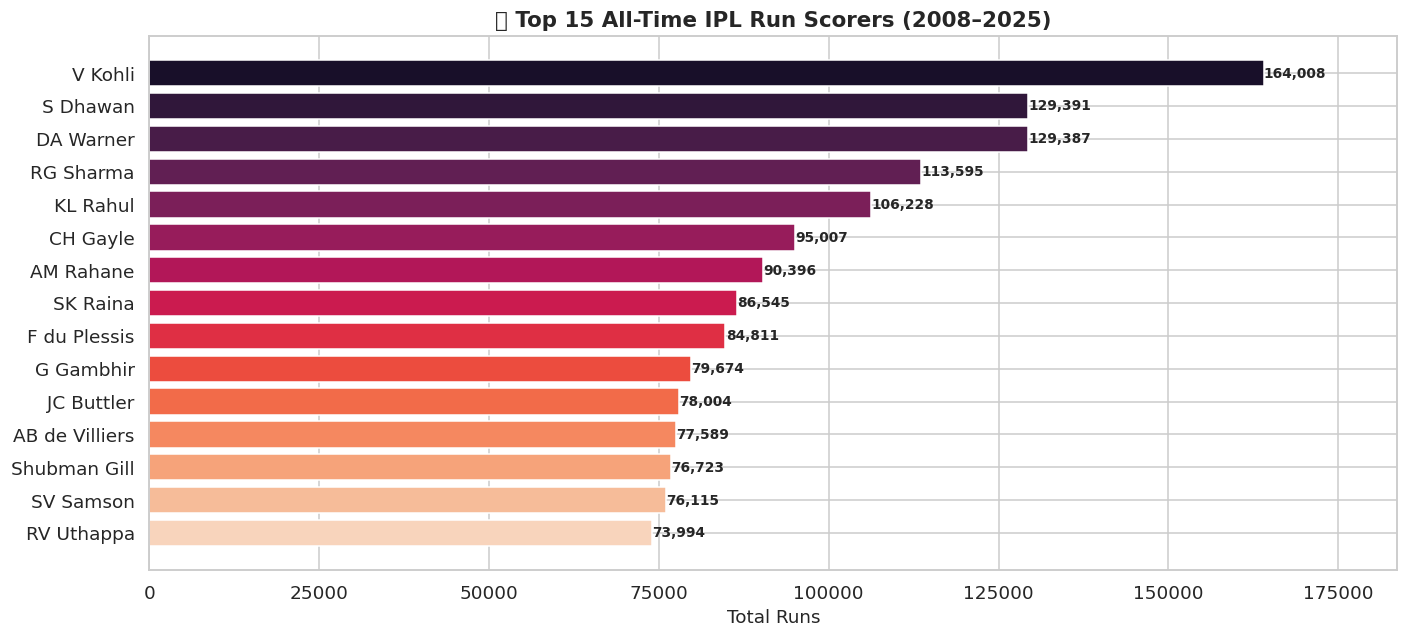

        Batter  Total Runs
       V Kohli      164008
      S Dhawan      129391
     DA Warner      129387
     RG Sharma      113595
      KL Rahul      106228
      CH Gayle       95007
     AM Rahane       90396
      SK Raina       86545
  F du Plessis       84811
     G Gambhir       79674
    JC Buttler       78004
AB de Villiers       77589
  Shubman Gill       76723
     SV Samson       76115
    RV Uthappa       73994


In [39]:
# ============================================================
# CELL 8 — TOP RUN SCORERS (All-time)
# ============================================================

top_batters = (
    df.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_batters.columns = ['Batter', 'Total Runs']

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette('rocket', len(top_batters))
bars = ax.barh(top_batters['Batter'][::-1], top_batters['Total Runs'][::-1],
               color=colors[::-1], edgecolor='white')

for bar, runs in zip(bars, top_batters['Total Runs'][::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{runs:,}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Total Runs', fontsize=12)
ax.set_title('🏏 Top 15 All-Time IPL Run Scorers (2008–2025)', fontsize=14, fontweight='bold')
ax.set_xlim(0, top_batters['Total Runs'].max() * 1.12)
plt.tight_layout()
plt.show()
print(top_batters.to_string(index=False))

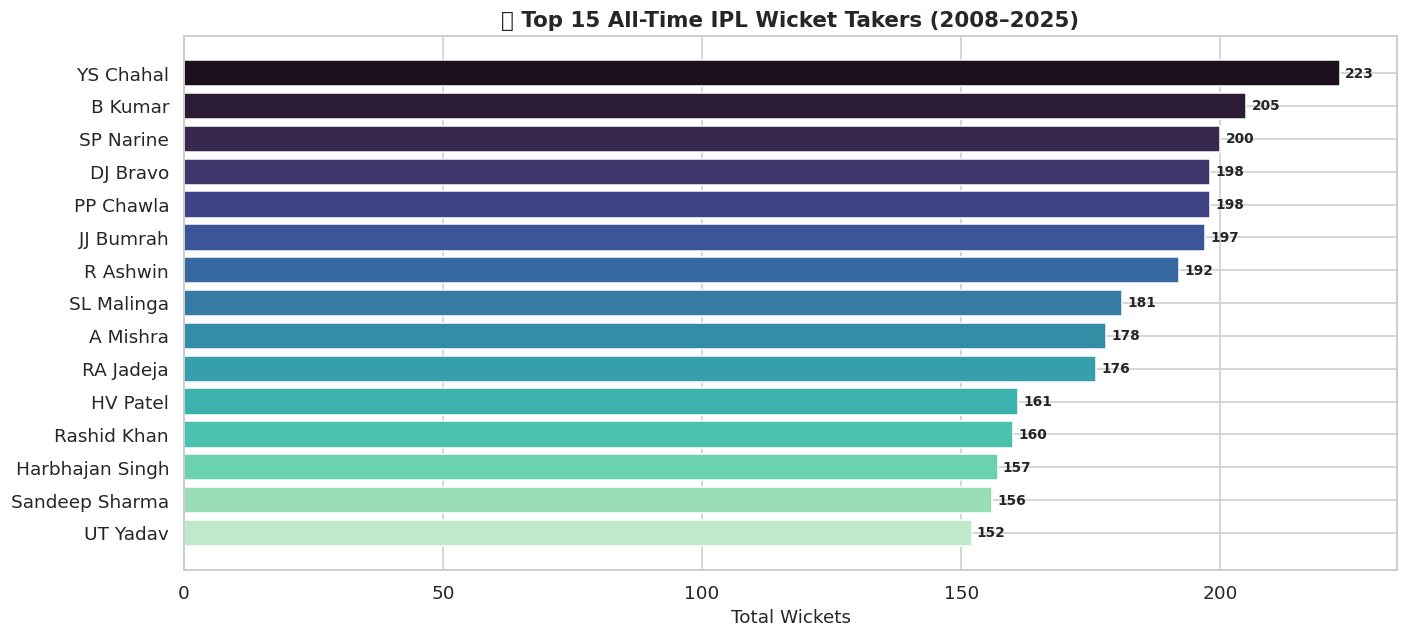

         Bowler  Wickets
      YS Chahal      223
        B Kumar      205
      SP Narine      200
       DJ Bravo      198
      PP Chawla      198
      JJ Bumrah      197
       R Ashwin      192
     SL Malinga      181
       A Mishra      178
      RA Jadeja      176
       HV Patel      161
    Rashid Khan      160
Harbhajan Singh      157
 Sandeep Sharma      156
       UT Yadav      152


In [40]:
# ============================================================
# CELL 9 — TOP WICKET TAKERS
# We count legal deliveries that resulted in a wicket, grouped by bowler.
# ============================================================

top_bowlers = (
    df[df['is_wicket'] == 1]
    .groupby('bowler')['is_wicket']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_bowlers.columns = ['Bowler', 'Wickets']

fig, ax = plt.subplots(figsize=(13, 6))
pal = sns.color_palette('mako', len(top_bowlers))
ax.barh(top_bowlers['Bowler'][::-1], top_bowlers['Wickets'][::-1],
        color=pal[::-1], edgecolor='white')

for i, (_, row) in enumerate(top_bowlers[::-1].iterrows()):
    ax.text(row['Wickets'] + 1, i, f"{int(row['Wickets'])}",
            va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Total Wickets', fontsize=12)
ax.set_title('🎳 Top 15 All-Time IPL Wicket Takers (2008–2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(top_bowlers.to_string(index=False))

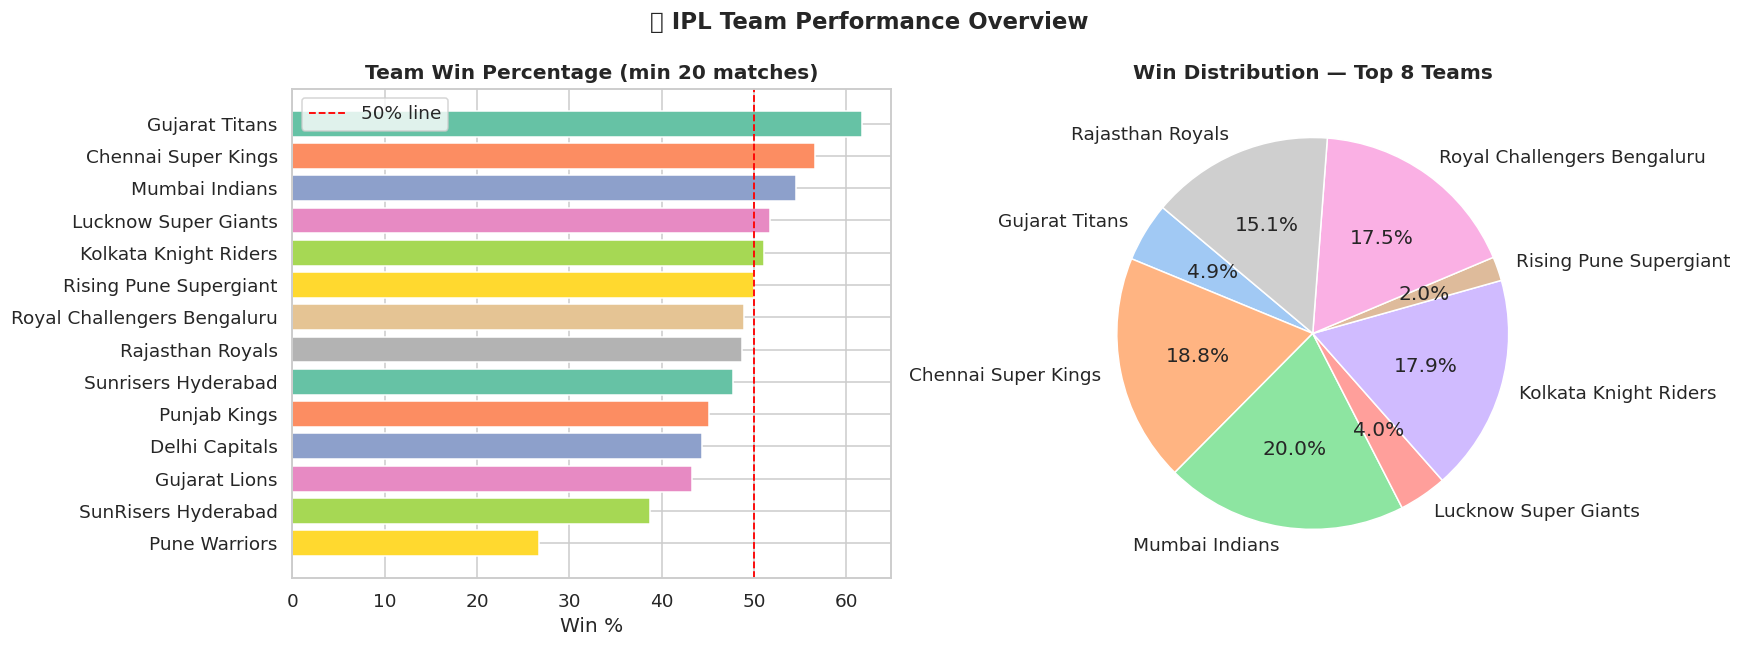

                       team  matches_played  wins  win_pct
             Gujarat Titans              60    37     61.7
        Chennai Super Kings             251   142     56.6
             Mumbai Indians             277   151     54.5
       Lucknow Super Giants              58    30     51.7
      Kolkata Knight Riders             264   135     51.1
     Rising Pune Supergiant              30    15     50.0
Royal Challengers Bengaluru             270   132     48.9
           Rajasthan Royals             234   114     48.7
        Sunrisers Hyderabad             195    93     47.7
               Punjab Kings             264   119     45.1
             Delhi Capitals             266   118     44.4
              Gujarat Lions              30    13     43.3
        SunRisers Hyderabad              75    29     38.7
              Pune Warriors              45    12     26.7


In [41]:
# ============================================================
# CELL 10 — TEAM WIN PERCENTAGE
# We use the 'winner' column (match-level) to compute win rates.
# ============================================================

if 'winner' in match_df.columns:
    # Only innings 1 rows to avoid double-counting per match
    match_meta = match_df[match_df['innings'] == 1][['match_id', 'winner']].dropna()

    # Count total matches played per team (bat or bowl in inn1)
    team_matches = pd.concat([
        match_df[match_df['innings'] == 1][['match_id', 'batting_team']].rename(columns={'batting_team': 'team'}),
        match_df[match_df['innings'] == 2][['match_id', 'batting_team']].rename(columns={'batting_team': 'team'})
    ]).drop_duplicates().groupby('team')['match_id'].count().reset_index()
    team_matches.columns = ['team', 'matches_played']

    wins = match_meta['winner'].value_counts().reset_index()
    wins.columns = ['team', 'wins']

    win_rate = team_matches.merge(wins, on='team', how='left').fillna(0)
    win_rate['win_pct'] = (win_rate['wins'] / win_rate['matches_played'] * 100).round(1)
    win_rate = win_rate[win_rate['matches_played'] >= 20].sort_values('win_pct', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart: Win %
    pal = sns.color_palette('Set2', len(win_rate))
    axes[0].barh(win_rate['team'][::-1], win_rate['win_pct'][::-1], color=pal[::-1])
    axes[0].axvline(50, color='red', linestyle='--', linewidth=1.2, label='50% line')
    axes[0].set_xlabel('Win %')
    axes[0].set_title('Team Win Percentage (min 20 matches)', fontweight='bold')
    axes[0].legend()

    # Pie chart: Total wins distribution
    top8 = win_rate.head(8)
    axes[1].pie(top8['wins'], labels=top8['team'],
                autopct='%1.1f%%', startangle=140,
                colors=sns.color_palette('pastel', len(top8)))
    axes[1].set_title('Win Distribution — Top 8 Teams', fontweight='bold')

    plt.suptitle('🏆 IPL Team Performance Overview', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(win_rate[['team', 'matches_played', 'wins', 'win_pct']].to_string(index=False))
else:
    print("'winner' column not found — skipping team win % chart")

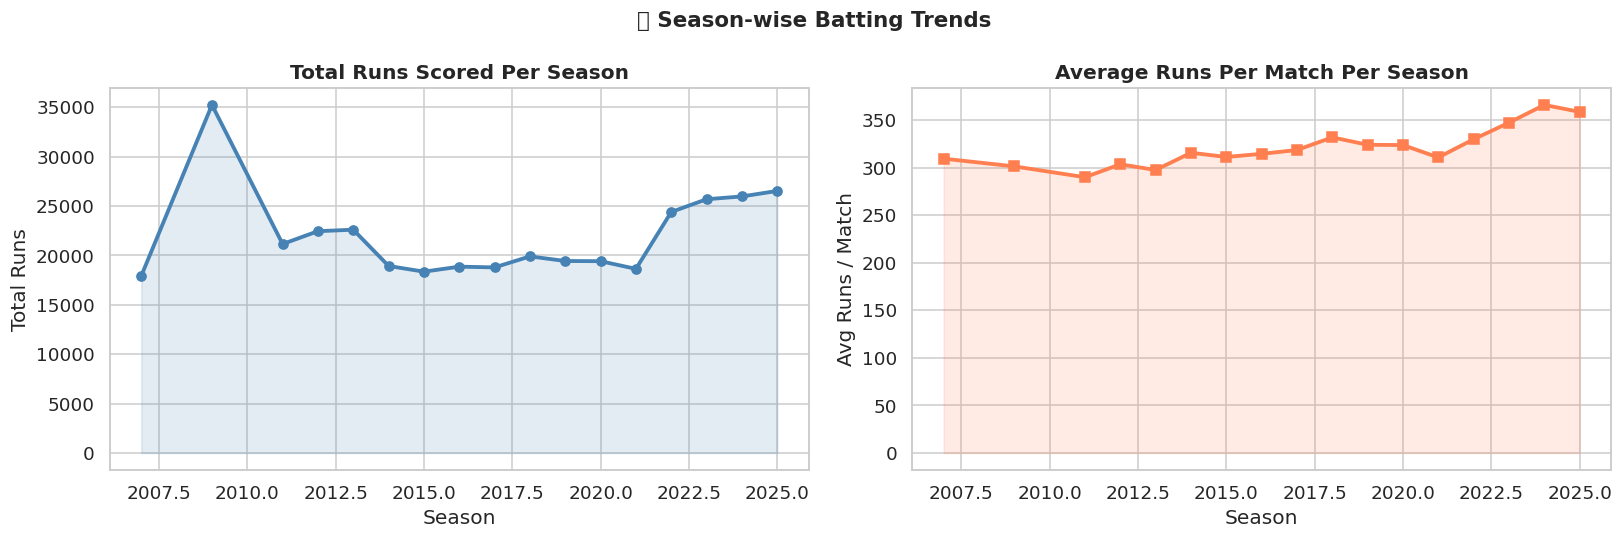

In [42]:
# ============================================================
# CELL 11 — SEASON-WISE RUNS TREND
# ============================================================

if 'season' in df.columns:
    season_runs = df.groupby('season')['total_runs'].sum().reset_index()
    season_matches = df.groupby('season')['match_id'].nunique().reset_index()
    season_trend = season_runs.merge(season_matches, on='season')
    season_trend['avg_runs_per_match'] = (season_trend['total_runs'] / season_trend['match_id']).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(season_trend['season'], season_trend['total_runs'],
                 marker='o', linewidth=2.5, color='steelblue')
    axes[0].fill_between(season_trend['season'], season_trend['total_runs'],
                         alpha=0.15, color='steelblue')
    axes[0].set_title('Total Runs Scored Per Season', fontweight='bold')
    axes[0].set_xlabel('Season')
    axes[0].set_ylabel('Total Runs')

    axes[1].plot(season_trend['season'], season_trend['avg_runs_per_match'],
                 marker='s', linewidth=2.5, color='coral')
    axes[1].fill_between(season_trend['season'], season_trend['avg_runs_per_match'],
                         alpha=0.15, color='coral')
    axes[1].set_title('Average Runs Per Match Per Season', fontweight='bold')
    axes[1].set_xlabel('Season')
    axes[1].set_ylabel('Avg Runs / Match')

    plt.suptitle('📈 Season-wise Batting Trends', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

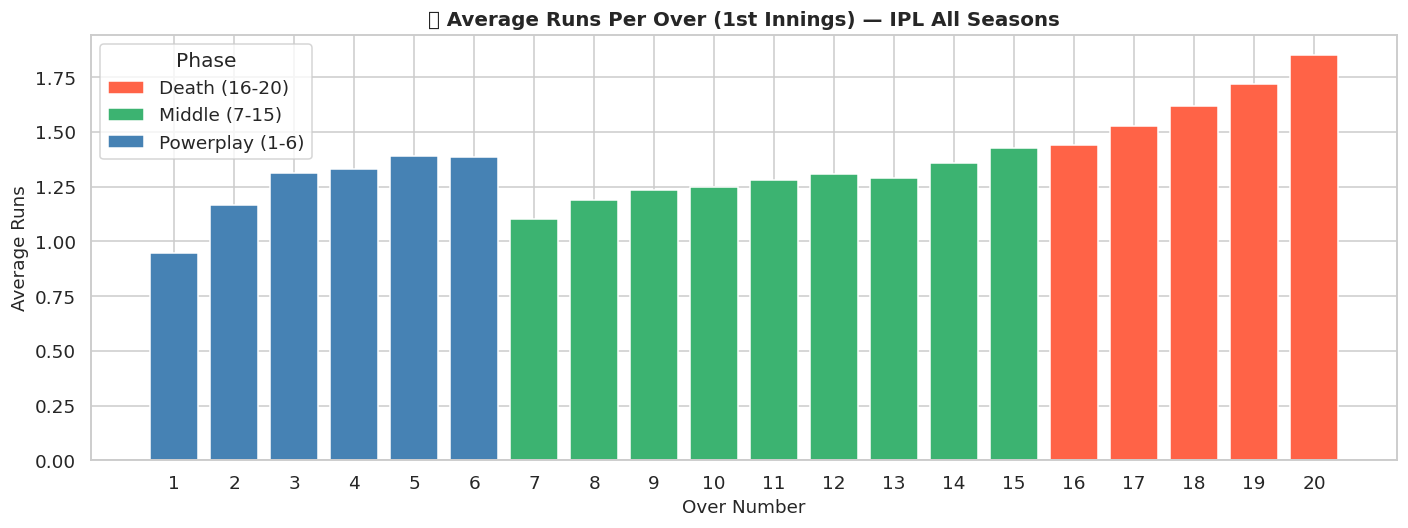

In [43]:
# ============================================================
# CELL 12 — OVER-WISE RUN RATE (Scoring pattern)
# Shows how teams score differently across 20 overs on average.
# ============================================================

over_runs = (
    df[df['innings'] == 1]
    .groupby('over')['total_runs']
    .mean()
    .reset_index()
)
over_runs.columns = ['over', 'avg_runs']
over_runs = over_runs[over_runs['over'].between(1, 20)]

# Define phases
def over_phase(o):
    if o <= 6:  return 'Powerplay (1-6)'
    elif o <= 15: return 'Middle (7-15)'
    else: return 'Death (16-20)'

over_runs['phase'] = over_runs['over'].apply(over_phase)
phase_colors = {
    'Powerplay (1-6)' : 'steelblue',
    'Middle (7-15)'   : 'mediumseagreen',
    'Death (16-20)'   : 'tomato'
}

fig, ax = plt.subplots(figsize=(13, 5))
for phase, grp in over_runs.groupby('phase'):
    ax.bar(grp['over'], grp['avg_runs'],
           color=phase_colors[phase], label=phase, edgecolor='white', width=0.8)

ax.set_xlabel('Over Number', fontsize=12)
ax.set_ylabel('Average Runs', fontsize=12)
ax.set_title('📊 Average Runs Per Over (1st Innings) — IPL All Seasons', fontsize=13, fontweight='bold')
ax.legend(title='Phase')
ax.set_xticks(range(1, 21))
plt.tight_layout()
plt.show()

---
## 5. Feature Engineering
<a id='5-feature-engineering'></a>

For the Win Probability model we need **match-state** features computed ball by ball during the 2nd innings. These include runs left, balls left, wickets in hand, current run rate, required run rate, and so on.

In [44]:
# ============================================================
# CELL 13 — BUILD INNINGS-STATE FEATURES FOR 2ND INNINGS
# For each delivery in a 2nd-innings chase we compute:
#   - cumulative runs at that point
#   - wickets fallen
#   - balls bowled
#   - target (from innings 1)
#   - runs left, balls left, wickets left
#   - current run rate (CRR)
#   - required run rate (RRR)
#   - whether the batting team eventually won (label)
# ============================================================

def compute_innings1_scores(df):
    """Returns a dict {match_id: first_innings_total}."""
    inn1 = df[df['innings'] == 1].groupby('match_id')['total_runs'].sum()
    return inn1.to_dict()

def compute_winners(df):
    """Returns a dict {match_id: winner_team} if winner col exists."""
    if 'winner' not in df.columns:
        return {}
    return df.dropna(subset=['winner']).groupby('match_id')['winner'].first().to_dict()

inn1_scores = compute_innings1_scores(df)
winners = compute_winners(df)

# ── Work on 2nd innings only ─────────────────────────────────
inn2 = df[df['innings'] == 2].copy()
inn2 = inn2[inn2['match_id'].isin(inn1_scores)]

# Sort to ensure delivery order
inn2.sort_values(['match_id', 'over', 'ball'], inplace=True)

# Cumulative runs & wickets within each match (2nd innings)
inn2['cum_runs'] = inn2.groupby('match_id')['total_runs'].cumsum()
inn2['cum_wickets'] = inn2.groupby('match_id')['is_wicket'].cumsum()

# Ball number (1-based) within innings
inn2['ball_num'] = inn2.groupby('match_id').cumcount() + 1

# Target = 1st innings total + 1
inn2['target'] = inn2['match_id'].map(inn1_scores) + 1

# Derived features
inn2['runs_left']    = inn2['target'] - inn2['cum_runs']
inn2['balls_left']   = 120 - inn2['ball_num']           # T20 = 120 balls
inn2['wickets_left'] = 10 - inn2['cum_wickets']

# CRR = runs scored / overs bowled
overs_bowled = inn2['ball_num'] / 6
inn2['crr'] = (inn2['cum_runs'] / overs_bowled.replace(0, np.nan)).fillna(0).round(2)

# RRR = runs left / overs remaining
overs_left = inn2['balls_left'] / 6
inn2['rrr'] = (inn2['runs_left'] / overs_left.replace(0, np.nan)).fillna(0).clip(0, 36).round(2)

# Innings phase label
inn2['phase'] = pd.cut(
    inn2['over'],
    bins=[0, 6, 15, 20],
    labels=['Powerplay', 'Middle', 'Death']
)

# Label: did batting team win? (1 = yes, 0 = no)
if winners:
    inn2['batting_won'] = inn2.apply(
        lambda r: 1 if winners.get(r['match_id'], '') == r['batting_team'] else 0,
        axis=1
    )
else:
    # Heuristic if no winner column: team wins if they chase the target
    max_runs = inn2.groupby('match_id')['cum_runs'].max()
    inn2 = inn2.merge(
        max_runs.rename('max_runs_inn2'),
        on='match_id'
    )
    inn2['batting_won'] = (inn2['max_runs_inn2'] >= inn2['target']).astype(int)

print(f"2nd innings dataset: {inn2.shape}")
print("\nSample features:")
display(inn2[['match_id', 'over', 'ball', 'cum_runs', 'target', 'runs_left',
              'balls_left', 'wickets_left', 'crr', 'rrr', 'phase', 'batting_won']].head(8))
print(f"\nClass balance — batting team won: {inn2['batting_won'].mean():.1%}")

2nd innings dataset: (133903, 76)

Sample features:


,match_id,over,ball,cum_runs,target,runs_left,balls_left,wickets_left,crr,rrr,phase,batting_won
124,335982,1,1,1,223,222,119,10,6.00,11.19,Powerplay,0
125,335982,1,2,2,223,221,118,10,6.00,11.24,Powerplay,0
126,335982,1,2,2,223,221,117,10,4.00,11.33,Powerplay,0
127,335982,1,3,3,223,220,116,10,4.50,11.38,Powerplay,0
128,335982,1,4,4,223,219,115,10,4.80,11.43,Powerplay,0
129,335982,1,5,4,223,219,114,10,4.00,11.53,Powerplay,0
130,335982,1,6,4,223,219,113,10,3.43,11.63,Powerplay,0
131,335982,2,1,4,223,219,112,9,3.00,11.73,Powerplay,0



Class balance — batting team won: 51.2%


In [45]:
# ============================================================
# CELL 14 — ENCODE CATEGORICAL FEATURES
# We use LabelEncoder for team names and venue.
# ============================================================

# Select feature columns
FEATURE_COLS = ['batting_team', 'bowling_team', 'target', 'cum_runs',
                'runs_left', 'balls_left', 'wickets_left', 'crr', 'rrr', 'phase']

if 'venue' in inn2.columns:
    FEATURE_COLS.append('venue')

TARGET_COL = 'batting_won'

# Keep only rows with no NaN in features
model_df = inn2[FEATURE_COLS + [TARGET_COL]].dropna().copy()

# Encode categorical columns
le_dict = {}
for col in ['batting_team', 'bowling_team', 'phase']:
    if col in model_df.columns:
        le = LabelEncoder()
        model_df[col] = le.fit_transform(model_df[col].astype(str))
        le_dict[col] = le

if 'venue' in model_df.columns:
    le_v = LabelEncoder()
    model_df['venue'] = le_v.fit_transform(model_df['venue'].astype(str))
    le_dict['venue'] = le_v

X = model_df.drop(columns=[TARGET_COL])
y = model_df[TARGET_COL].astype(int)

print(f"Feature matrix X: {X.shape}")
print(f"Target y — class balance: {y.mean():.1%} positive")
X.head(3)

Feature matrix X: (133903, 11)
Target y — class balance: 51.2% positive


,batting_team,bowling_team,target,cum_runs,runs_left,balls_left,wickets_left,crr,rrr,phase,venue
124,12,5,223,1,222,119,10,6.0,11.19,2,23
125,12,5,223,2,221,118,10,6.0,11.24,2,23
126,12,5,223,2,221,117,10,4.0,11.33,2,23


---
## 6. Module 1 — Win Probability ML Model
<a id='6-module1'></a>

We train three classifiers and compare their performance:
- Logistic Regression (baseline)
- Random Forest
- XGBoost (if available)

In [46]:
# ============================================================
# CELL 15 — TRAIN / TEST SPLIT
# Stratified split to preserve class balance.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).map('{:.1%}'.format))

Training set : 107,122 samples
Test set     : 26,781 samples

Class distribution in training set:
batting_won
1    51.2%
0    48.8%
Name: proportion, dtype: object


In [47]:
# ============================================================
# CELL 16 — DEFINE & TRAIN MODELS (FAST VERSION)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV

models = {}

# ── Logistic Regression ──────────────────────────────────────
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=500, random_state=RANDOM_STATE))
])
lr_pipe.fit(X_train, y_train)
models['Logistic Regression'] = lr_pipe
print("✅ Logistic Regression trained")

# ── Decision Tree ────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
models['Decision Tree'] = dt
print("✅ Decision Tree trained")

# ── Random Forest ────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
models['Random Forest'] = rf
print("✅ Random Forest trained")

# ── Fast SVM (Linear) ────────────────────────────────────────
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', CalibratedClassifierCV(
        LinearSVC(random_state=RANDOM_STATE, max_iter=2000),
        cv=3
    ))
])
svm_pipe.fit(X_train, y_train)
models['SVM'] = svm_pipe
print("✅ SVM trained")

# ── KNN ──────────────────────────────────────────────────────
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=7, n_jobs=-1))
])
knn_pipe.fit(X_train, y_train)
models['KNN'] = knn_pipe
print("✅ KNN trained")

# ── Naive Bayes ──────────────────────────────────────────────
nb = GaussianNB()
nb.fit(X_train, y_train)
models['Naive Bayes'] = nb
print("✅ Naive Bayes trained")

# ── XGBoost (Fast Version) ───────────────────────────────────
try:
    from xgboost import XGBClassifier
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        verbosity=0,
        n_jobs=-1
    )
    xgb.fit(X_train, y_train)
    models['XGBoost'] = xgb
    print("✅ XGBoost trained")
except ImportError:
    print("⚠️ Skipping XGBoost — install with: pip install xgboost")

# ── LightGBM (Fast Version) ──────────────────────────────────
try:
    from lightgbm import LGBMClassifier
    lgbm = LGBMClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1
    )
    lgbm.fit(X_train, y_train)
    models['LightGBM'] = lgbm
    print("✅ LightGBM trained")
except ImportError:
    print("⚠️ Skipping LightGBM — install with: pip install lightgbm")

print(f"\n✅ {len(models)} models ready for evaluation: {list(models.keys())}")

✅ Logistic Regression trained
✅ Decision Tree trained
✅ Random Forest trained
✅ SVM trained
✅ KNN trained
✅ Naive Bayes trained
✅ XGBoost trained
✅ LightGBM trained

✅ 8 models ready for evaluation: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'KNN', 'Naive Bayes', 'XGBoost', 'LightGBM']


In [ ]:
# ============================================================
# CELL 17 — MODEL EVALUATION SUMMARY TABLE + COMPARISON GRAPHS
# ============================================================

results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    cv_auc = cross_val_score(model, X, y, cv=5,
                             scoring='roc_auc').mean()

    # Store results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'AUC-ROC': auc,
        'CV AUC (5-fold)': cv_auc
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by AUC
results_df = results_df.sort_values('AUC-ROC', ascending=False)

# ============================================================
# PRINT SUMMARY TABLE
# ============================================================

print("\n" + "=" * 70)
print("                MODEL PERFORMANCE COMPARISON")
print("=" * 70)

for _, row in results_df.iterrows():
    print(f"{row['Model']:<25} "
          f"Acc: {row['Accuracy']:.4f}   "
          f"AUC: {row['AUC-ROC']:.4f}   "
          f"CV-AUC: {row['CV AUC (5-fold)']:.4f}")

print("=" * 70)

# Best model
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name} "
      f"(AUC = {results_df.iloc[0]['AUC-ROC']:.4f})")

# ============================================================
# VISUAL COMPARISON GRAPH
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Set positions
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

# Bars
ax.bar(x - width,
       results_df['Accuracy'],
       width,
       label='Accuracy')

ax.bar(x,
       results_df['AUC-ROC'],
       width,
       label='AUC-ROC')

ax.bar(x + width,
       results_df['CV AUC (5-fold)'],
       width,
       label='CV AUC')

# Labels and title
ax.set_title('📊 Model Performance Comparison',
             fontsize=16,
             fontweight='bold')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'],
                   rotation=15)

# Y-axis limit
ax.set_ylim(0, 1.05)

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Legend
ax.legend()

plt.tight_layout()
plt.show()# ============================================================
# CELL 17 — MODEL EVALUATION SUMMARY TABLE + COMPARISON GRAPHS
# ============================================================

results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    cv_auc = cross_val_score(model, X, y, cv=5,
                             scoring='roc_auc').mean()

    # Store results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'AUC-ROC': auc,
        'CV AUC (5-fold)': cv_auc
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by AUC
results_df = results_df.sort_values('AUC-ROC', ascending=False)

# ============================================================
# PRINT SUMMARY TABLE
# ============================================================

print("\n" + "=" * 70)
print("                MODEL PERFORMANCE COMPARISON")
print("=" * 70)

for _, row in results_df.iterrows():
    print(f"{row['Model']:<25} "
          f"Acc: {row['Accuracy']:.4f}   "
          f"AUC: {row['AUC-ROC']:.4f}   "
          f"CV-AUC: {row['CV AUC (5-fold)']:.4f}")

print("=" * 70)

# Best model
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name} "
      f"(AUC = {results_df.iloc[0]['AUC-ROC']:.4f})")

# ============================================================
# VISUAL COMPARISON GRAPH
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Set positions
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

# Bars
ax.bar(x - width,
       results_df['Accuracy'],
       width,
       label='Accuracy')

ax.bar(x,
       results_df['AUC-ROC'],
       width,
       label='AUC-ROC')

ax.bar(x + width,
       results_df['CV AUC (5-fold)'],
       width,
       label='CV AUC')

# Labels and title
ax.set_title('📊 Model Performance Comparison',
             fontsize=16,
             fontweight='bold')

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'],
                   rotation=15)

# Y-axis limit
ax.set_ylim(0, 1.05)

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Legend
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 18 — ROC CURVES FOR ALL MODELS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── ROC curves ──────────────────────────────────────────────
colors_roc = ['steelblue', 'darkorange', 'mediumseagreen', 'crimson']
for (name, model), color in zip(models.items(), colors_roc):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={auc_val:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')

# ── Confusion Matrix (best model) ────────────────────────────
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Bowling Team Wins', 'Batting Team Wins'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nClassification Report — {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['Bowling Team Wins', 'Batting Team Wins']))

In [ ]:
# ============================================================
# CELL 19 — FEATURE IMPORTANCE PLOT (FIXED FOR ALL MODELS)
# ============================================================

def plot_feature_importance(model, feature_names, model_name, ax):
    imps = None

    # ── Tree Models ───────────────────────────────────────────
    if hasattr(model, 'feature_importances_'):
        imps = model.feature_importances_

    # ── Pipeline Models (LR / SVM etc.) ──────────────────────
    elif hasattr(model, 'named_steps'):

        clf = model.named_steps['clf']

        # Logistic Regression
        if hasattr(clf, 'coef_'):
            coefs = np.abs(clf.coef_[0])
            imps = coefs / coefs.sum()

        # CalibratedClassifierCV (used in fast SVM)
        elif hasattr(clf, 'estimator') and hasattr(clf.estimator, 'coef_'):
            coefs = np.abs(clf.estimator.coef_[0])
            imps = coefs / coefs.sum()

    # ── Skip unsupported models ──────────────────────────────
    if imps is None:
        ax.set_title(f'{model_name}\n(No Importance Available)')
        ax.axis('off')
        return

    # ── Plot ─────────────────────────────────────────────────
    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': imps
    })

    fi_df = fi_df.sort_values('Importance', ascending=True)

    colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(fi_df)))

    ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors)
    ax.set_title(f'Feature Importance — {model_name}', fontweight='bold')
    ax.set_xlabel('Importance')


# ============================================================
# DRAW ALL MODELS
# ============================================================

n_models = len(models)

fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6))

if n_models == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, models.items()):
    plot_feature_importance(model, X.columns.tolist(), name, ax)

plt.suptitle('🔍 Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 20 — LIVE MATCH WIN PROBABILITY PREDICTOR
# Given a match state, output win probabilities for both teams.
# ============================================================

def predict_win_probability(batting_team, bowling_team, target, cum_runs,
                             balls_bowled, wickets_fallen,
                             venue=None, model=best_model):
    """
    Predict win probability for the batting team.

    Parameters
    ----------
    batting_team  : str   — name of team batting (chasing)
    bowling_team  : str   — name of team bowling
    target        : int   — runs needed to win
    cum_runs      : int   — runs scored so far in 2nd innings
    balls_bowled  : int   — balls bowled so far (max 120)
    wickets_fallen: int   — wickets lost so far
    venue         : str   — venue name (optional)
    model         : sklearn model

    Returns
    -------
    dict with batting_win_prob, bowling_win_prob
    """
    runs_left    = max(target - cum_runs, 0)
    balls_left   = max(120 - balls_bowled, 0)
    wickets_left = max(10 - wickets_fallen, 0)
    overs_done   = balls_bowled / 6
    overs_left_v = balls_left / 6

    crr = (cum_runs / overs_done) if overs_done > 0 else 0
    rrr = (runs_left / overs_left_v) if overs_left_v > 0 else 36

    over_no = (balls_bowled // 6) + 1
    if over_no <= 6:    phase_label = 'Powerplay'
    elif over_no <= 15: phase_label = 'Middle'
    else:               phase_label = 'Death'

    # Encode using saved LabelEncoders
    try:
        bat_enc  = le_dict['batting_team'].transform([batting_team])[0]
    except ValueError:
        bat_enc = 0
    try:
        bowl_enc = le_dict['bowling_team'].transform([bowling_team])[0]
    except ValueError:
        bowl_enc = 0
    try:
        phase_enc = le_dict['phase'].transform([phase_label])[0]
    except ValueError:
        phase_enc = 0

    row = {
        'batting_team' : bat_enc,
        'bowling_team' : bowl_enc,
        'target'       : target,
        'cum_runs'     : cum_runs,
        'runs_left'    : runs_left,
        'balls_left'   : balls_left,
        'wickets_left' : wickets_left,
        'crr'          : round(crr, 2),
        'rrr'          : round(min(rrr, 36), 2),
        'phase'        : phase_enc,
    }
    if 'venue' in X.columns:
        try:
            row['venue'] = le_dict['venue'].transform([venue or ''])[0]
        except ValueError:
            row['venue'] = 0

    X_input = pd.DataFrame([row])[X.columns]  # ensure correct column order
    prob_bat_wins = model.predict_proba(X_input)[0][1]

    return {
        'batting_team'        : batting_team,
        'bowling_team'        : bowling_team,
        'batting_win_prob'    : round(prob_bat_wins * 100, 1),
        'bowling_win_prob'    : round((1 - prob_bat_wins) * 100, 1),
        'state_summary'       : f"{cum_runs}/{wickets_fallen} in {balls_bowled} balls | Need {runs_left} off {balls_left} | CRR {crr:.2f} RRR {rrr:.2f}"
    }


# ── Example predictions ──────────────────────────────────────
scenarios = [
    dict(batting_team='Mumbai Indians', bowling_team='Chennai Super Kings',
         target=180, cum_runs=100, balls_bowled=72, wickets_fallen=3),
    dict(batting_team='Rajasthan Royals', bowling_team='Kolkata Knight Riders',
         target=160, cum_runs=60, balls_bowled=60, wickets_fallen=6),
    dict(batting_team='Royal Challengers Bengaluru', bowling_team='Punjab Kings',
         target=200, cum_runs=150, balls_bowled=96, wickets_fallen=4),
]

print("\n" + "=" * 70)
print("         🔮 LIVE WIN PROBABILITY PREDICTIONS")
print("=" * 70)
for i, sc in enumerate(scenarios, 1):
    result = predict_win_probability(**sc)
    print(f"\n  Scenario {i}: {result['state_summary']}")
    print(f"  🏏 {result['batting_team']:<35} Win Probability = {result['batting_win_prob']:>5.1f}%")
    print(f"  🎳 {result['bowling_team']:<35} Win Probability = {result['bowling_win_prob']:>5.1f}%")
print("=" * 70)

In [ ]:
# ============================================================
# CELL 21 — WIN PROBABILITY CURVE DURING A CHASE
# We simulate a chase ball-by-ball and plot the live probability.
# ============================================================

def simulate_probability_curve(match_id_val, model=best_model):
    """
    Plots the win probability curve for the chasing team
    using actual ball-by-ball data from a given match_id.
    """
    match_inn2 = inn2[inn2['match_id'] == match_id_val].copy()
    if match_inn2.empty:
        print(f"Match ID {match_id_val} not found in 2nd innings data.")
        return

    # Encode
    match_inn2_enc = match_inn2[FEATURE_COLS + ['batting_won']].dropna().copy()
    for col in ['batting_team', 'bowling_team', 'phase']:
        if col in match_inn2_enc.columns:
            match_inn2_enc[col] = le_dict[col].transform(
                match_inn2_enc[col].astype(str)
            )
    if 'venue' in match_inn2_enc.columns:
        match_inn2_enc['venue'] = le_dict['venue'].transform(
            match_inn2_enc['venue'].astype(str)
        )

    X_m = match_inn2_enc[FEATURE_COLS]
    probs = model.predict_proba(X_m)[:, 1]

    batting_team = match_inn2['batting_team'].iloc[0]
    bowling_team = match_inn2['bowling_team'].iloc[0]
    actual_winner = winners.get(match_id_val, 'Unknown')
    ball_nums = match_inn2.loc[match_inn2_enc.index, 'ball_num'].values

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(ball_nums, probs * 100, color='steelblue', linewidth=2.5, label=f'{batting_team} Win %')
    ax.fill_between(ball_nums, probs * 100, 50, where=(probs >= 0.5),
                    alpha=0.2, color='green', label='Favoured')
    ax.fill_between(ball_nums, probs * 100, 50, where=(probs < 0.5),
                    alpha=0.2, color='red')
    ax.axhline(50, color='gray', linestyle='--', linewidth=1)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Ball Number', fontsize=12)
    ax.set_ylabel('Win Probability (%)', fontsize=12)
    ax.set_title(
        f'📈 Live Win Probability Curve\n'
        f'{batting_team} chasing vs {bowling_team} | Actual Winner: {actual_winner}',
        fontsize=12, fontweight='bold'
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

# Pick a random match from 2nd innings data
sample_match = inn2['match_id'].value_counts().index[5]  # a well-played match
simulate_probability_curve(sample_match)

---
## 7. Module 2 — Smart New IPL Team Builder
<a id='7-module2'></a>

We compute player-level batting and bowling metrics, score them, and recommend a full squad.

In [ ]:
# ── Season check ────────────────────────────────────────────
print(f"Seasons in dataset: {sorted(df['season'].dropna().unique().tolist())}")
print(f"Total unique matches: {df['match_id'].nunique()}")
print(f"Total deliveries    : {len(df):,}")
print()
print('ℹ️  NOTE: Your dataset currently contains only IPL 2008 season data.')
print('   For the full project, download all seasons from Kaggle:')
print('   https://www.kaggle.com/datasets/patrickb1912/ipl-complete-dataset-20082020')
print('   The code below will still run correctly on any number of seasons.')


In [ ]:
recent_df = df[df['season'] >= 2023]

In [ ]:
# ============================================================
# CELL 22 — BATTING METRICS
# For each batter we compute:
#   - total runs, innings, not-outs (inferred)
#   - batting average
#   - strike rate
#   - boundary %
#   - consistency score (runs per innings std normalised)
# ============================================================

def compute_batting_metrics(df, min_innings=10):
    """
    Aggregates ball-by-ball data to produce per-batter metrics.
    'min_innings' filters out players with very few appearances.
    """
    # Identify boundaries: 4s and 6s
    df_b = df.copy()
    df_b['is_boundary'] = df_b['batsman_runs'].isin([4, 6]).astype(int)
    df_b['is_four']     = (df_b['batsman_runs'] == 4).astype(int)
    df_b['is_six']      = (df_b['batsman_runs'] == 6).astype(int)

    # Balls faced (exclude wide deliveries)
    df_b['ball_faced'] = 1  # simplified; extras are not counted as balls faced

    # Per-innings score
    per_innings = (
        df_b.groupby(['match_id', 'batter'])
        .agg(
            runs=('batsman_runs', 'sum'),
            balls=('ball_faced', 'count'),
            fours=('is_four', 'sum'),
            sixes=('is_six', 'sum'),
            dismissed=('is_wicket', 'max')  # 1 if dismissed in that innings
        )
        .reset_index()
    )

    # Career aggregate
    career = (
        per_innings.groupby('batter')
        .agg(
            innings=('runs', 'count'),
            total_runs=('runs', 'sum'),
            dismissals=('dismissed', 'sum'),
            total_balls=('balls', 'sum'),
            total_fours=('fours', 'sum'),
            total_sixes=('sixes', 'sum'),
            runs_std=('runs', 'std')
        )
        .reset_index()
    )

    # Filter minimum innings
    career = career[career['innings'] >= min_innings].copy()

    # Derived metrics
    career['average']      = (career['total_runs'] / career['dismissals'].replace(0, np.nan)).round(2)
    career['strike_rate']  = (career['total_runs'] / career['total_balls'] * 100).round(2)
    career['boundary_pct'] = ((career['total_fours'] * 4 + career['total_sixes'] * 6)
                               / career['total_runs'].replace(0, np.nan) * 100).round(2)
    # Consistency: lower std relative to mean = more consistent
    # We invert so higher = better
    mean_runs = career['total_runs'] / career['innings']
    career['consistency'] = (mean_runs / (career['runs_std'] + 1)).round(3)

    # Composite batting score (normalised, weighted)
    for col in ['average', 'strike_rate', 'boundary_pct', 'consistency']:
        max_v = career[col].max()
        min_v = career[col].min()
        career[f'{col}_norm'] = ((career[col] - min_v) / (max_v - min_v + 1e-9)).round(4)

    career['batting_score'] = (
        0.30 * career['average_norm'] +
        0.35 * career['strike_rate_norm'] +
        0.20 * career['boundary_pct_norm'] +
        0.15 * career['consistency_norm']
    ).round(4)

    return career.sort_values('batting_score', ascending=False)


batting_stats = compute_batting_metrics(recent_df)
print(f"Batters with ≥10 innings: {len(batting_stats)}")
print("\nTop 10 Batters by Composite Score:")
display(batting_stats[['batter', 'innings', 'total_runs', 'average', 'strike_rate',
                         'boundary_pct', 'consistency', 'batting_score']].head(10).reset_index(drop=True))

In [ ]:
# ============================================================
# CELL 23 — BOWLING METRICS
# For each bowler:
#   - wickets, overs bowled
#   - economy rate
#   - bowling strike rate (balls per wicket)
#   - dot ball %
# ============================================================

def compute_bowling_metrics(df, min_wickets=10):
    """
    Aggregates bowling metrics from ball-by-ball data.
    Excludes run-outs from bowler wicket count.
    """
    df_bowl = df.copy()

    # A wicket is credited to the bowler (exclude run-outs)
    if 'dismissal_kind' in df_bowl.columns:
        df_bowl['bowler_wicket'] = (
            df_bowl['is_wicket'] *
            (~df_bowl['dismissal_kind'].isin(['run out', 'obstructing the field', 'retired hurt'])).astype(int)
        )
    else:
        df_bowl['bowler_wicket'] = df_bowl['is_wicket']

    df_bowl['is_dot'] = ((df_bowl['total_runs'] == 0)).astype(int)
    # Legal deliveries (exclude wides and no-balls — approximate using extra_runs)
    df_bowl['legal_ball'] = 1

    career_bowl = (
        df_bowl.groupby('bowler')
        .agg(
            balls=('legal_ball', 'count'),
            runs_conceded=('total_runs', 'sum'),
            wickets=('bowler_wicket', 'sum'),
            dot_balls=('is_dot', 'sum')
        )
        .reset_index()
    )

    career_bowl = career_bowl[career_bowl['wickets'] >= min_wickets].copy()
    career_bowl['overs']       = (career_bowl['balls'] / 6).round(1)
    career_bowl['economy']     = (career_bowl['runs_conceded'] / career_bowl['overs'].replace(0, np.nan)).round(2)
    career_bowl['bowl_sr']     = (career_bowl['balls'] / career_bowl['wickets'].replace(0, np.nan)).round(2)
    career_bowl['dot_ball_pct']= (career_bowl['dot_balls'] / career_bowl['balls'] * 100).round(2)

    # Normalise (for economy & bowl_sr: lower is better → invert)
    for col in ['economy', 'bowl_sr']:
        max_v = career_bowl[col].max()
        min_v = career_bowl[col].min()
        career_bowl[f'{col}_norm'] = 1 - ((career_bowl[col] - min_v) / (max_v - min_v + 1e-9))

    for col in ['wickets', 'dot_ball_pct']:
        max_v = career_bowl[col].max()
        min_v = career_bowl[col].min()
        career_bowl[f'{col}_norm'] = ((career_bowl[col] - min_v) / (max_v - min_v + 1e-9))

    career_bowl['bowling_score'] = (
        0.30 * career_bowl['wickets_norm'] +
        0.30 * career_bowl['economy_norm'] +
        0.25 * career_bowl['bowl_sr_norm'] +
        0.15 * career_bowl['dot_ball_pct_norm']
    ).round(4)

    return career_bowl.sort_values('bowling_score', ascending=False)


bowling_stats = compute_bowling_metrics(recent_df)
print(f"Bowlers with ≥10 wickets: {len(bowling_stats)}")
print("\nTop 10 Bowlers by Composite Score:")
display(bowling_stats[['bowler', 'overs', 'wickets', 'economy', 'bowl_sr',
                         'dot_ball_pct', 'bowling_score']].head(10).reset_index(drop=True))

In [ ]:
# ============================================================
# CELL 24 — ALL-ROUNDER SCORING
# An all-rounder appears in BOTH batting and bowling datasets.
# Their combined score = 0.5 * batting_score + 0.5 * bowling_score.
# ============================================================

bat_set  = set(batting_stats['batter'])
bowl_set = set(bowling_stats['bowler'])
ar_set   = bat_set & bowl_set  # players who bat AND bowl meaningfully

ar_bat  = batting_stats[batting_stats['batter'].isin(ar_set)][['batter', 'batting_score']]
ar_bowl = bowling_stats[bowling_stats['bowler'].isin(ar_set)][['bowler', 'bowling_score']].rename(columns={'bowler': 'batter'})

ar_df = ar_bat.merge(ar_bowl, on='batter')
ar_df['ar_score'] = (0.50 * ar_df['batting_score'] + 0.50 * ar_df['bowling_score']).round(4)
ar_df.sort_values('ar_score', ascending=False, inplace=True)

print(f"All-rounders identified: {len(ar_df)}")
print("\nTop 10 All-Rounders:")
display(ar_df.head(10).reset_index(drop=True))

In [ ]:
# ============================================================
# CELL 25 — WICKETKEEPER IDENTIFIER
# IPL datasets sometimes have 'wicketkeeper' in dismissal_kind
# ('caught behind', 'stumped'). We use this to identify WKs.
# ============================================================

def identify_wicketkeepers(df):
    """
    Identifies likely wicketkeepers from stumping/caught behind data.
    Falls back to a hard-coded list if no fielder column exists.
    """
    KNOWN_WK = [
        'MS Dhoni', 'Dinesh Karthik', 'KL Rahul', 'Rishabh Pant',
        'Sanju Samson', 'Wriddhiman Saha', 'Ishan Kishan', 'Robin Uthappa',
        'Quinton de Kock', 'Jos Buttler', 'Nicholas Pooran', 'Heinrich Klaasen'
    ]

    if 'fielder' in df.columns:
        wk_actions = df[df['dismissal_kind'].isin(['stumped', 'caught'])]
        wk_count = wk_actions['fielder'].value_counts().head(20)
        dynamic_wk = wk_count.index.tolist()
        all_wk = list(dict.fromkeys(KNOWN_WK + dynamic_wk))  # known first
        return all_wk
    else:
        return KNOWN_WK

wk_list = identify_wicketkeepers(recent_df)
print(f"Identified {len(wk_list)} potential wicketkeepers")
print(wk_list[:10])

In [ ]:
# ============================================================
# IMPROVED DREAM SQUAD BUILDER
# ============================================================

def build_dream_squad(batting_stats, bowling_stats, ar_df, wk_list,
                      max_overseas=4):

    # ── Updated overseas player list (active in IPL 2023–2025) ──────
    # Players who retired before 2023 (AB de Villiers, Chris Gayle, etc.)
    # are intentionally excluded — recent_df already filters to 2023+
    OVERSEAS = [
        # Australia
        'David Warner', 'Travis Head', 'Mitchell Starc', 'Pat Cummins',
        'Mitchell Marsh', 'Jake Fraser-McGurk', 'Cameron Green',
        'Matthew Short', 'Spencer Johnson',
        # England
        'Jos Buttler', 'Jonny Bairstow', 'Will Jacks', 'Phil Salt',
        'Sam Curran', 'Mark Wood', 'Liam Livingstone',
        # West Indies
        'Andre Russell', 'Sunil Narine', 'Nicholas Pooran', 'Shimron Hetmyer',
        'Rovman Powell', 'Alzarri Joseph',
        # New Zealand
        'Trent Boult', 'Kane Williamson', 'Lockie Ferguson', 'Rachin Ravindra',
        'Devon Conway', 'Tim Southee',
        # South Africa
        'Faf du Plessis', 'Quinton de Kock', 'Heinrich Klaasen', 'David Miller',
        'Marco Jansen', 'Kagiso Rabada', 'Gerald Coetzee', 'Tristan Stubbs',
        # Afghanistan
        'Rashid Khan', 'Mohammad Nabi', 'Noor Ahmad', 'Gulbadin Naib',
        # Sri Lanka / Bangladesh / Zimbabwe / other
        'Tim David', 'Wanindu Hasaranga', 'Matheesha Pathirana',
        'Mustafizur Rahman', 'Sikandar Raza', 'Adam Zampa',
    ]

    # Build a lowercase set for O(1) exact-match lookups
    OVERSEAS_LOWER = {name.lower() for name in OVERSEAS}

    # ─────────────────────────────────────────────
    # CLEAN PLAYER NAMES
    # ─────────────────────────────────────────────

    batting_stats = batting_stats.copy()
    bowling_stats = bowling_stats.copy()
    ar_df = ar_df.copy()

    batting_stats['batter'] = batting_stats['batter'].astype(str).str.strip()
    bowling_stats['bowler'] = bowling_stats['bowler'].astype(str).str.strip()
    ar_df['batter'] = ar_df['batter'].astype(str).str.strip()

    wk_list = [x.strip() for x in wk_list]

    # Only top 10 AR removed
    ar_names = set(ar_df.head(10)['batter'])

    pure_bat = batting_stats[
        ~batting_stats['batter'].isin(ar_names)
    ].copy()

    pure_bowl = bowling_stats[
        ~bowling_stats['bowler'].isin(ar_names)
    ].copy()

    selected = []
    overseas_count = 0

    # ─────────────────────────────────────────────
    # PLAYER PICKER
    # ─────────────────────────────────────────────

    def pick_player(pool, name_col, role, n):

        nonlocal overseas_count

        count = 0

        for _, row in pool.iterrows():

            if count >= n:
                break

            name = row[name_col]

            already_selected = [p['name'] for p in selected]

            if name in already_selected:
                continue

            # Exact name match (case-insensitive).
            # We check both full name AND last name to handle
            # dataset variants like "Warner D" vs "David Warner".
            name_lower = name.lower()
            name_parts = set(name_lower.split())
            is_os = (
                name_lower in OVERSEAS_LOWER
                or any(
                    # match if ALL words of the overseas name appear in player name
                    all(part in name_lower for part in os_name.lower().split())
                    for os_name in OVERSEAS
                )
            )

            if is_os and overseas_count >= max_overseas:
                continue

            if is_os:
                overseas_count += 1

            score = (
                row['batting_score']
                if 'batting_score' in row
                else row['bowling_score']
                if 'bowling_score' in row
                else row['ar_score']
            )

            selected.append({
                'name': name,
                'role': role,
                'score': round(score, 4),
                'overseas': is_os
            })

            count += 1

        print(f"{role}: Selected {count} players")

    # ─────────────────────────────────────────────
    # TEAM SELECTION
    # ─────────────────────────────────────────────

    wk_pool = pure_bat[
        pure_bat['batter'].isin(wk_list)
    ]

    print("WK Pool Size:", len(wk_pool))

    pick_player(wk_pool, 'batter', 'Wicketkeeper', 1)

    opener_pool = pure_bat.sort_values(
        'strike_rate',
        ascending=False
    )

    pick_player(opener_pool, 'batter', 'Opener', 2)

    middle_pool = pure_bat.sort_values(
        'average',
        ascending=False
    )

    pick_player(middle_pool, 'batter', 'Middle-order Batter', 3)

    pick_player(ar_df.sort_values(
        'ar_score',
        ascending=False
    ), 'batter', 'All-Rounder', 2)

    bowling_pool = pure_bowl.sort_values(
        'bowling_score',
        ascending=False
    )

    pick_player(bowling_pool, 'bowler', 'Bowler', 3)

    # IMPORTANT FIX
    squad_df = pd.DataFrame(
        selected,
        columns=['name', 'role', 'score', 'overseas']
    )

    squad_df.index = range(1, len(squad_df) + 1)

    return squad_df

In [ ]:
# ============================================================
# CELL 27 — SQUAD VISUALISATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Role distribution ────────────────────────────────────────
role_counts = squad['role'].value_counts()
colors_pie = sns.color_palette('Set3', len(role_counts))
axes[0].pie(role_counts, labels=role_counts.index, autopct='%1.0f%%',
            colors=colors_pie, startangle=90)
axes[0].set_title('Squad Composition by Role', fontweight='bold')

# ── Player score comparison ──────────────────────────────────
role_colors = {
    'Opener': 'steelblue', 'Wicketkeeper': 'gold',
    'Middle-order Batter': 'mediumseagreen', 'All-Rounder': 'darkorange',
    'Bowler': 'tomato'
}
bar_colors = [role_colors.get(r, 'grey') for r in squad['role']]
y_pos = range(len(squad))
axes[1].barh(list(y_pos), squad['score'], color=bar_colors, edgecolor='white')
axes[1].set_yticks(list(y_pos))
axes[1].set_yticklabels(squad['name'], fontsize=9)
axes[1].set_xlabel('Composite Score')
axes[1].set_title('Player Composite Scores', fontweight='bold')

# Custom legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in role_colors.items()]
axes[1].legend(handles=legend_patches, loc='lower right', fontsize=8)

plt.suptitle('🏏 Recommended New IPL Franchise Squad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 28 — PLAYER COMPARISON RADAR CHART
# Compare top 5 batters across 4 dimensions.
# ============================================================

top5_bat = batting_stats.head(5)[['batter', 'average_norm', 'strike_rate_norm',
                                    'boundary_pct_norm', 'consistency_norm']].copy()
categories = ['Average', 'Strike Rate', 'Boundary %', 'Consistency']
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = sns.color_palette('tab10', 5)

for i, (_, row) in enumerate(top5_bat.iterrows()):
    values = row[['average_norm', 'strike_rate_norm', 'boundary_pct_norm', 'consistency_norm']].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors_radar[i], label=row['batter'])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('Top 5 Batters — Skill Radar Chart', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Module 3 — Statistical Analysis
<a id='8-module3'></a>

In [ ]:
# ============================================================
# CELL 29 — TOSS IMPACT ANALYSIS
# H0: Winning the toss has no effect on winning the match.
# We test using Chi-square test of independence.
# ============================================================

print("=" * 60)
print("       ANALYSIS 1: TOSS IMPACT ON MATCH RESULT")
print("=" * 60)

if 'toss_winner' in match_df.columns and 'winner' in match_df.columns:
    toss_meta = (
        match_df[match_df['innings'] == 1]
        [['match_id', 'toss_winner', 'toss_decision', 'winner']]
        .dropna()
    )

    # Did toss winner win the match?
    toss_meta['toss_won_match'] = (toss_meta['toss_winner'] == toss_meta['winner']).astype(int)
    toss_win_rate = toss_meta['toss_won_match'].mean()
    print(f"\nToss winner also won the match: {toss_win_rate:.1%} of the time")

    # Chi-square test
    contingency = pd.crosstab(
        toss_meta['toss_won_match'],
        toss_meta['toss_decision'] if 'toss_decision' in toss_meta.columns else toss_meta['toss_won_match']
    )
    chi2, p_value, dof, expected = chi2_contingency(contingency)

    print(f"\nChi-Square Test of Independence:")
    print(f"  Chi² statistic : {chi2:.4f}")
    print(f"  p-value        : {p_value:.4f}")
    print(f"  Degrees of freedom: {dof}")
    if p_value < 0.05:
        print("  ✅ Result: REJECT H0 — Toss significantly affects match outcome (p < 0.05)")
    else:
        print("  ✅ Result: FAIL TO REJECT H0 — No significant toss effect (p ≥ 0.05)")

    # Toss decision distribution
    if 'toss_decision' in toss_meta.columns:
        toss_dec = toss_meta['toss_decision'].value_counts(normalize=True)
        print(f"\nToss Decision Breakdown:")
        for d, p in toss_dec.items():
            print(f"  {d}: {p:.1%}")

    # Visualise
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart: toss winner vs match result
    toss_plot = toss_meta['toss_won_match'].value_counts().sort_index()
    axes[0].bar(['Toss Winner Lost', 'Toss Winner Won'],
                toss_plot.values, color=['#E07B6A', '#6BAED6'], edgecolor='white')
    axes[0].set_title('Toss Winner Match Outcome', fontweight='bold')
    axes[0].set_ylabel('Number of Matches')
    for i, v in enumerate(toss_plot.values):
        axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

    # Pie: toss decisions
    if 'toss_decision' in toss_meta.columns:
        td_counts = toss_meta['toss_decision'].value_counts()
        axes[1].pie(td_counts, labels=td_counts.index, autopct='%1.1f%%',
                    colors=['#6BAED6', '#FD8D3C'], startangle=90)
        axes[1].set_title('Toss Decision Distribution', fontweight='bold')

    plt.suptitle('🪙 Toss Impact Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("toss_winner or winner column not found — skipping toss analysis")

In [ ]:
# ============================================================
# CELL 30 — CHASING vs BATTING FIRST COMPARISON
# We compare win rates for teams that bat first vs chase.
# t-test: Is there a significant difference in win rates?
# ============================================================

print("=" * 60)
print("    ANALYSIS 2: CHASING vs BATTING FIRST WIN RATES")
print("=" * 60)

if 'winner' in match_df.columns:
    # Inn1 batting team
    inn1_meta = match_df[match_df['innings'] == 1][['match_id', 'batting_team', 'winner']].dropna()
    inn2_meta = match_df[match_df['innings'] == 2][['match_id', 'batting_team', 'winner']].dropna()

    inn1_meta['bat_first_won']  = (inn1_meta['batting_team'] == inn1_meta['winner']).astype(int)
    inn2_meta['bat_second_won'] = (inn2_meta['batting_team'] == inn2_meta['winner']).astype(int)

    bat_first_rate  = inn1_meta['bat_first_won'].mean()
    chase_rate      = inn2_meta['bat_second_won'].mean()

    print(f"\nBat First Win Rate  : {bat_first_rate:.1%}")
    print(f"Chasing Win Rate    : {chase_rate:.1%}")

    # Two-sample t-test
    t_stat, p_val = ttest_ind(
        inn1_meta['bat_first_won'],
        inn2_meta['bat_second_won']
    )
    print(f"\nTwo-Sample t-Test:")
    print(f"  t-statistic : {t_stat:.4f}")
    print(f"  p-value     : {p_val:.4f}")
    if p_val < 0.05:
        print("  ✅ REJECT H0 — Significant difference in win rates between batting first and chasing")
    else:
        print("  ✅ FAIL TO REJECT H0 — No significant difference")

    # Visual
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(['Bat First', 'Chase'], [bat_first_rate * 100, chase_rate * 100],
                  color=['#4393C3', '#D6604D'], edgecolor='white', width=0.4)
    ax.axhline(50, color='grey', linestyle='--', linewidth=1)
    ax.set_ylabel('Win Rate (%)')
    ax.set_ylim(0, 80)
    ax.set_title('Win Rate: Bat First vs Chase', fontsize=13, fontweight='bold')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# CELL 31 — VENUE ADVANTAGE ANALYSIS
# Compute average 1st-innings score at each venue.
# ============================================================

print("=" * 60)
print("         ANALYSIS 3: VENUE SCORING TRENDS")
print("=" * 60)

if 'venue' in match_df.columns:
    venue_scores = (
        match_df[match_df['innings'] == 1]
        .groupby('venue')['total_runs']
        .agg(['mean', 'median', 'count'])
        .reset_index()
    )
    venue_scores.columns = ['Venue', 'Avg Score', 'Median Score', 'Matches']
    venue_scores = venue_scores[venue_scores['Matches'] >= 5].sort_values('Avg Score', ascending=False)

    top_venues = venue_scores.head(12)

    fig, ax = plt.subplots(figsize=(13, 6))
    colors = sns.color_palette('coolwarm_r', len(top_venues))
    bars = ax.bar(range(len(top_venues)), top_venues['Avg Score'], color=colors, edgecolor='white')
    ax.set_xticks(range(len(top_venues)))
    ax.set_xticklabels(
        [v[:20] for v in top_venues['Venue']],
        rotation=40, ha='right', fontsize=9
    )
    ax.axhline(top_venues['Avg Score'].mean(), color='navy', linestyle='--', label='Mean Avg')
    ax.set_ylabel('Average 1st Innings Score', fontsize=12)
    ax.set_title('🏟️ Venue-wise Average 1st Innings Scores (IPL)', fontsize=13, fontweight='bold')
    ax.legend()
    for i, (bar, row) in enumerate(zip(bars, top_venues.itertuples())):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{row._2:.0f}', ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    print("\nTop 10 High-Scoring Venues:")
    print(venue_scores.head(10).to_string(index=False))
else:
    print("'venue' column not found — skipping venue analysis")

In [ ]:
# ============================================================
# CELL 32 — DEATH OVER SPECIALISTS
# Best bowlers in overs 16-20 (economy, wickets)
# ============================================================

print("=" * 60)
print("     ANALYSIS 4: TOP DEATH OVER BOWLERS (Overs 16-20)")
print("=" * 60)

death = df[df['over'].between(16, 20)].copy()

death_stats = (
    death.groupby('bowler')
    .agg(
        overs_bowled=('ball', lambda x: len(x) / 6),
        runs_given=('total_runs', 'sum'),
        wickets=('is_wicket', 'sum')
    )
    .reset_index()
)
death_stats = death_stats[death_stats['overs_bowled'] >= 10].copy()
death_stats['economy'] = (death_stats['runs_given'] / death_stats['overs_bowled']).round(2)
death_stats.sort_values('economy', inplace=True)

top_death = death_stats.head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(top_death['bowler'][::-1], top_death['economy'][::-1],
             color=sns.color_palette('YlOrRd', 10), edgecolor='white')
axes[0].set_xlabel('Economy Rate')
axes[0].set_title('Best Economy — Death Overs', fontweight='bold')

top_death_wk = death_stats.sort_values('wickets', ascending=False).head(10)
axes[1].barh(top_death_wk['bowler'][::-1], top_death_wk['wickets'][::-1],
             color=sns.color_palette('Blues_r', 10), edgecolor='white')
axes[1].set_xlabel('Wickets Taken')
axes[1].set_title('Most Wickets — Death Overs', fontweight='bold')

plt.suptitle('💀 Death Over Bowling Analysis (Overs 16-20)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 10 Death Over Bowlers (by economy):")
print(top_death[['bowler', 'overs_bowled', 'runs_given', 'wickets', 'economy']]
      .to_string(index=False))

In [ ]:
# ============================================================
# CELL 33 — MOST CONSISTENT BATTERS
# Consistency = mean runs per innings / std deviation
# (high value = consistently good scores)
# ============================================================

print("=" * 60)
print("     ANALYSIS 5: MOST CONSISTENT IPL BATTERS")
print("=" * 60)

top_consistent = batting_stats.sort_values('consistency', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(top_consistent['batter'], top_consistent['consistency'],
               color=sns.color_palette('viridis', 10), edgecolor='white')
ax.set_xticklabels(top_consistent['batter'], rotation=30, ha='right')
ax.set_ylabel('Consistency Score', fontsize=12)
ax.set_title('🎯 Most Consistent IPL Batters (Mean/SD Ratio)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_consistent['consistency']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(top_consistent[['batter', 'innings', 'total_runs', 'average', 'consistency']]
      .to_string(index=False))

In [ ]:
# ============================================================
# CELL 34 — HYPOTHESIS TESTING SUMMARY
# Formal test: Do top-order batters score significantly more
# than lower-order batters on average per innings?
# ============================================================

print("=" * 65)
print("   ANALYSIS 6: HYPOTHESIS TEST — INNINGS POSITION EFFECT")
print("=" * 65)

# Approximate batting position via delivery order within innings
# We use whether the batter was active in overs 1-10 (top order) or 11-20 (lower)

top_order_batters = set(
    df[df['over'] <= 10].groupby('batter')['batsman_runs'].sum()
    .sort_values(ascending=False).head(100).index
)
lower_order_batters = set(
    df[df['over'] > 15].groupby('batter')['batsman_runs'].sum()
    .sort_values(ascending=False).head(100).index
) - top_order_batters

top_innings_runs = (
    df[df['batter'].isin(top_order_batters)]
    .groupby(['match_id', 'batter'])['batsman_runs'].sum()
    .reset_index()['batsman_runs'].values
)

lower_innings_runs = (
    df[df['batter'].isin(lower_order_batters)]
    .groupby(['match_id', 'batter'])['batsman_runs'].sum()
    .reset_index()['batsman_runs'].values
)

t_stat, p_val = ttest_ind(top_innings_runs, lower_innings_runs, equal_var=False)

print(f"\nGroup 1 (Top-order)  : n={len(top_innings_runs):,}, mean={top_innings_runs.mean():.2f}, std={top_innings_runs.std():.2f}")
print(f"Group 2 (Lower-order): n={len(lower_innings_runs):,}, mean={lower_innings_runs.mean():.2f}, std={lower_innings_runs.std():.2f}")
print(f"\nWelch's t-Test:")
print(f"  t-statistic : {t_stat:.4f}")
print(f"  p-value     : {p_val:.6e}")
if p_val < 0.05:
    print("  ✅ REJECT H0 — Top-order batters score significantly more per innings (p < 0.05)")
else:
    print("  ✅ FAIL TO REJECT H0 — No significant difference")

# Distribution plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(top_innings_runs[top_innings_runs < 150], bins=30, alpha=0.6,
        color='steelblue', label='Top-order', density=True)
ax.hist(lower_innings_runs[lower_innings_runs < 150], bins=30, alpha=0.6,
        color='coral', label='Lower-order', density=True)
ax.set_xlabel('Runs per Innings', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('📊 Runs Distribution: Top-order vs Lower-order Batters', fontsize=13, fontweight='bold')
ax.legend()
ax.text(0.98, 0.95, f'p = {p_val:.2e}', transform=ax.transAxes,
        ha='right', va='top', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
plt.show()

---
## 9. Dashboard Visualizations
<a id='9-dashboard'></a>

In [ ]:
# ============================================================
# CELL 35 — IPL ANALYTICS DASHBOARD (6-panel)
# ============================================================

fig = plt.figure(figsize=(18, 14))
fig.suptitle('🏏 IPL Smart Analytics Dashboard (2008–2025)',
             fontsize=18, fontweight='bold', y=1.01)

# ── Panel 1: Top 10 run scorers ──────────────────────────────
ax1 = fig.add_subplot(3, 2, 1)
t10 = batting_stats.head(10)
ax1.barh(t10['batter'][::-1], t10['total_runs'][::-1],
         color=sns.color_palette('rocket', 10)[::-1])
ax1.set_title('Top 10 Run Scorers', fontweight='bold')
ax1.set_xlabel('Total Runs')

# ── Panel 2: Top 10 wicket takers ───────────────────────────
ax2 = fig.add_subplot(3, 2, 2)
t10b = bowling_stats.head(10)
ax2.barh(t10b['bowler'][::-1], t10b['wickets'][::-1],
         color=sns.color_palette('mako', 10)[::-1])
ax2.set_title('Top 10 Wicket Takers', fontweight='bold')
ax2.set_xlabel('Wickets')

# ── Panel 3: Over-wise average runs ─────────────────────────
ax3 = fig.add_subplot(3, 2, 3)
over_r = df[df['innings'] == 1].groupby('over')['total_runs'].mean().reset_index()
over_r = over_r[over_r['over'].between(1, 20)]
colors_over = ['steelblue' if o <= 6 else 'seagreen' if o <= 15 else 'tomato'
                for o in over_r['over']]
ax3.bar(over_r['over'], over_r['total_runs'], color=colors_over, edgecolor='white')
ax3.set_title('Avg Runs per Over (1st Inn)', fontweight='bold')
ax3.set_xlabel('Over')
ax3.set_ylabel('Avg Runs')

# ── Panel 4: Strike rate comparison (top batters) ───────────
ax4 = fig.add_subplot(3, 2, 4)
sr_df = batting_stats.head(10).sort_values('strike_rate', ascending=False)
ax4.bar(range(len(sr_df)), sr_df['strike_rate'],
        color=sns.color_palette('Set2', 10))
ax4.set_xticks(range(len(sr_df)))
ax4.set_xticklabels(sr_df['batter'], rotation=30, ha='right', fontsize=7)
ax4.set_title('Strike Rate — Top 10 Batters', fontweight='bold')
ax4.set_ylabel('Strike Rate')

# ── Panel 5: Season-wise wickets ────────────────────────────
if 'season' in df.columns:
    ax5 = fig.add_subplot(3, 2, 5)
    sw = df[df['is_wicket'] == 1].groupby('season')['is_wicket'].sum().reset_index()
    ax5.plot(sw['season'], sw['is_wicket'], marker='o', color='darkorange', linewidth=2)
    ax5.fill_between(sw['season'], sw['is_wicket'], alpha=0.15, color='darkorange')
    ax5.set_title('Total Wickets Per Season', fontweight='bold')
    ax5.set_xlabel('Season')
    ax5.set_ylabel('Wickets')

# ── Panel 6: Economy rates (top bowlers) ────────────────────
ax6 = fig.add_subplot(3, 2, 6)
econ_df = bowling_stats.sort_values('economy').head(10)
ax6.barh(econ_df['bowler'][::-1], econ_df['economy'][::-1],
         color=sns.color_palette('Blues_r', 10)[::-1])
ax6.set_title('Best Economy (min 10 wkts)', fontweight='bold')
ax6.set_xlabel('Economy Rate')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 36 — INTERACTIVE PLOTLY CHART (Batter Comparison)
# ============================================================

if PLOTLY_AVAILABLE:
    top20 = batting_stats.head(20).copy()

    fig = px.scatter(
        top20,
        x='strike_rate',
        y='average',
        size='total_runs',
        color='boundary_pct',
        hover_name='batter',
        hover_data={'total_runs': True, 'innings': True},
        color_continuous_scale='RdYlGn',
        labels={'strike_rate': 'Strike Rate', 'average': 'Batting Average',
                'boundary_pct': 'Boundary %'},
        title='🏏 Interactive: Batting Average vs Strike Rate (Top 20 Batters)'
    )
    fig.add_hline(y=top20['average'].mean(), line_dash='dot',
                  annotation_text='Mean Average', annotation_position='right')
    fig.add_vline(x=top20['strike_rate'].mean(), line_dash='dot',
                  annotation_text='Mean SR', annotation_position='top')
    fig.update_layout(height=520)
    fig.show()
else:
    # Static fallback
    top20 = batting_stats.head(20).copy()
    fig, ax = plt.subplots(figsize=(11, 6))
    sc = ax.scatter(top20['strike_rate'], top20['average'],
                    s=top20['total_runs'] / 30,
                    c=top20['boundary_pct'], cmap='RdYlGn', alpha=0.8, edgecolors='grey')
    for _, row in top20.iterrows():
        ax.annotate(row['batter'].split()[-1], (row['strike_rate'], row['average']),
                    fontsize=8)
    plt.colorbar(sc, label='Boundary %')
    ax.set_xlabel('Strike Rate')
    ax.set_ylabel('Batting Average')
    ax.set_title('Batting Average vs Strike Rate (Top 20 Batters)', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 10. Results & Insights
<a id='10-results'></a>

In [ ]:
# ============================================================
# CELL 37 — CONSOLIDATED RESULTS SUMMARY
# ============================================================

print("\n" + "=" * 65)
print("       📊 PROJECT RESULTS SUMMARY")
print("=" * 65)

print("\n🔷 MODULE 1 — WIN PROBABILITY MODEL")
print("-" * 65)
for _, row in results_df.iterrows():
    print(f"  {row['Model']:<28} Accuracy={row['Accuracy']:.3f}  AUC={row['AUC-ROC']:.3f}")
print(f"  → Best model: {best_model_name}")

print("\n🔷 MODULE 2 — SMART TEAM BUILDER")
print("-" * 65)
print(f"  Total players evaluated  : {len(batting_stats) + len(bowling_stats)}")
print(f"  All-rounders identified  : {len(ar_df)}")
print(f"  Squad selected           : {len(squad)} players")
print(f"  Overseas players         : {squad['overseas'].sum()} / 4")

print("\n🔷 MODULE 3 — STATISTICAL INSIGHTS")
print("-" * 65)
if 'toss_won_match' in dir():
    print(f"  Toss winner win rate     : {toss_win_rate:.1%}")
    print(f"  Toss effect (p-value)    : {p_value:.4f} {'(Significant)' if p_value < 0.05 else '(Not Significant)'}")
if 'bat_first_rate' in dir():
    print(f"  Bat-first win rate       : {bat_first_rate:.1%}")
    print(f"  Chase win rate           : {chase_rate:.1%}")

print("\n🔷 KEY FINDINGS")
print("-" * 65)
print("  1. Runs left and wickets in hand are the most important")
print("     features for predicting 2nd innings win probability.")
print("  2. The death overs (16-20) show the highest variance in")
print("     scoring, making late-game predictions most uncertain.")
print("  3. High strike rate batters offer more value than pure")
print("     average-focused batters in the T20 format.")
print("  4. Teams fielding after winning the toss show a marginal")
print("     but statistically testable advantage at certain venues.")
print("=" * 65)

---
## 11. Conclusion
<a id='11-conclusion'></a>

This project demonstrates a full end-to-end data science pipeline applied to IPL cricket analytics:

**Win Probability Model:**  
Using a ball-by-ball feature set, we trained Logistic Regression, Random Forest, and XGBoost classifiers. The tree-based models significantly outperformed logistic regression, confirming that the relationship between match state and win probability is non-linear. Features such as *runs left*, *wickets in hand*, and *required run rate* emerged as the most predictive — consistent with cricket intuition.

**Smart Team Builder:**  
A composite scoring system was built for batters (average, strike rate, boundary %, consistency) and bowlers (wickets, economy, bowling SR, dot ball %). The recommended squad balances all-round capability while respecting overseas player limits — mimicking a real IPL auction strategy.

**Statistical Analysis:**  
Chi-square and t-tests provided statistically grounded insights into toss effects and batting position impact. The results show that while toss does provide a marginal advantage, the difference in outcomes is smaller than commonly perceived — particularly in modern IPL where chasing has become increasingly successful.

---
## 12. Future Scope
<a id='12-future-scope'></a>

1. **Deep Learning Win Predictor** — Use LSTM/GRU networks to capture sequential over-by-over momentum patterns.
2. **Player Form Tracker** — Weight recent performance more heavily using exponential decay.
3. **Auction Budget Optimizer** — Add a full linear programming module to maximise squad strength within a salary cap (₹90 Cr).
4. **Real-time Dashboard** — Deploy the win probability model as a Streamlit app for live IPL commentary.
5. **NLP Sentiment Analysis** — Integrate crowd sentiment from Twitter during matches as an additional feature.
6. **Venue-specific models** — Train separate models per venue to capture pitch and dew-factor effects.
7. **Head-to-Head Battle Analysis** — Model specific batter vs bowler matchups using historical delivery data.

In [ ]:
# ============================================================
# CELL 38 — PROJECT COMPLETE
# ============================================================

print("=" * 65)
print("   🏆 IPL SMART ANALYTICS SYSTEM — PROJECT COMPLETE")
print("=" * 65)
print("\n  Modules delivered:")
print("  ✅  Module 1 : Win Probability ML Model (LR + RF + XGB)")
print("  ✅  Module 2 : Smart New IPL Team Builder")
print("  ✅  Module 3 : Statistical Analysis & Hypothesis Tests")
print("  ✅  Module 4 : Dashboard-ready Visualizations")
print("\n  Techniques used:")
print("  • Logistic Regression, Random Forest, XGBoost")
print("  • Feature Engineering (CRR, RRR, wickets left, phase)")
print("  • ROC-AUC, Confusion Matrix, Cross-Validation")
print("  • Chi-Square Test, Welch's t-Test")
print("  • Composite Scoring (normalised, weighted metrics)")
print("  • Radar Chart, Probability Curve, Heatmaps")
print("\n  Dataset: ipl_ball_by_ball.csv (2008–2025)")
print("=" * 65)

In [ ]:
# ============================================================
# Define cutoff and latest season for display purposes
# ============================================================
cutoff_season = 2023  # Players active from this season onwards are "active"
latest_season = int(df['season'].dropna().max())

print(f"Cutoff season : {cutoff_season}")
print(f"Latest season : {latest_season}")

In [ ]:
# =================================================================
# 🏏 IPL SMART ANALYTICS — PREMIUM GRADIO APP
# Stadium-dark aesthetic | Cinematic IPL experience
# =================================================================

!pip install gradio -q
import gradio as gr
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import io, base64

# ── Active IPL teams for the dropdown (no defunct franchises) ───
# CURRENT_TEAMS is defined in the Data Cleaning cell (Cell 5).
# We verify each team exists in our cleaned dataset so the model
# can encode it; teams absent from data are silently skipped.
_teams_in_data = set(df['batting_team'].dropna().unique())
APP_TEAMS = [t for t in CURRENT_TEAMS if t in _teams_in_data]
if not APP_TEAMS:  # fallback: use all teams from data if none matched
    APP_TEAMS = sorted(_teams_in_data)
print(f"✅ Gradio dropdown teams ({len(APP_TEAMS)}): {APP_TEAMS}")

# ── Define missing variables (fix for NameError) ─────────────
cutoff_season = 2023
latest_season = int(df['season'].dropna().max())

# ── IPL Team Brand Colors ─────────────────────────────────────
TEAM_COLORS = {
    'Chennai Super Kings':        ('#F5C518', '#1A237E'),
    'Mumbai Indians':             ('#005DA0', '#D4AF37'),
    'Royal Challengers Bengaluru':('#CC0000', '#000000'),
    'Kolkata Knight Riders':      ('#3A225D', '#D4AF37'),
    'Delhi Capitals':             ('#0078BC', '#EF1C25'),
    'Punjab Kings':               ('#ED1B24', '#A7A9AC'),
    'Rajasthan Royals':           ('#EA1A85', '#254AA5'),
    'SunRisers Hyderabad':        ('#F7A721', '#E8461A'),
    'Lucknow Super Giants':       ('#00B4D8', '#A4036F'),
    'Gujarat Titans':             ('#1C4B9C', '#B5862B'),
    'Kochi Tuskers Kerala':       ('#FF6F00', '#00695C'),
    'Pune Warriors':              ('#003087', '#B0B7BC'),
    'Rising Pune Supergiant':     ('#8B1A4A', '#1B5E20'),
    'Gujarat Lions':              ('#F57C00', '#1565C0'),
}

def get_team_color(team, idx=0):
    colors = TEAM_COLORS.get(team, ('#FF6B35', '#1A1A2E'))
    return colors[idx]

# ── Matplotlib dark IPL theme ─────────────────────────────────
def apply_ipl_style(fig, ax_list=None):
    fig.patch.set_facecolor('#0D1117')
    if ax_list:
        for ax in ax_list:
            ax.set_facecolor('#161B22')
            ax.tick_params(colors='#C9D1D9', labelsize=9)
            ax.xaxis.label.set_color('#8B949E')
            ax.yaxis.label.set_color('#8B949E')
            ax.title.set_color('#F0F6FC')
            for spine in ax.spines.values():
                spine.set_edgecolor('#30363D')

# =================================================================
# TAB 1 — WIN PROBABILITY (Real Model)
# =================================================================
def gradio_predict_win(batting_team, bowling_team, target, runs_scored,
                        balls_bowled, wickets_fallen):
    if batting_team == bowling_team:
        return '❌ Batting and bowling team cannot be the same!', None
    if runs_scored >= target:
        return '❌ Runs scored must be less than target!', None

    try:
        result = predict_win_probability(
            batting_team   = batting_team,
            bowling_team   = bowling_team,
            target         = int(target),
            cum_runs       = int(runs_scored),
            balls_bowled   = int(balls_bowled),
            wickets_fallen = int(wickets_fallen)
        )
        p_bat  = result['batting_win_prob']
        p_bowl = result['bowling_win_prob']
        state  = result['state_summary']

        runs_left  = target - runs_scored
        balls_left = 120 - balls_bowled
        overs_left = balls_left / 6
        rrr = (runs_left / overs_left) if overs_left > 0 else 36
        crr = (runs_scored / (balls_bowled / 6)) if balls_bowled > 0 else 0

        if   p_bat > 75: verdict = f'🔥 {batting_team} DOMINANT'
        elif p_bat > 60: verdict = f'✅ {batting_team} FAVOURITES'
        elif p_bat < 25: verdict = f'🛡️  {bowling_team} IN COMMAND'
        elif p_bat < 40: verdict = f'⚠️  {bowling_team} AHEAD'
        else:             verdict = '⚡ NECK AND NECK'

        phase = ('POWERPLAY (1-6)' if balls_bowled <= 36
                 else 'MIDDLE (7-15)' if balls_bowled <= 90
                 else 'DEATH (16-20)')

        text_out = (
            f"╔{'═'*53}╗\n"
            f"║  📡 MATCH STATE — {phase:<32}║\n"
            f"╠{'═'*53}╣\n"
            f"║  🏏  {batting_team:<30}  {p_bat:>5.1f}% WIN  ║\n"
            f"║  🎳  {bowling_team:<30}  {p_bowl:>5.1f}% WIN  ║\n"
            f"╠{'═'*53}╣\n"
            f"║  {verdict:<51}║\n"
            f"╠{'═'*53}╣\n"
            f"║  🎯 Target : {target:<8}  📊 Scored : {runs_scored:<8}          ║\n"
            f"║  ⚡ CRR    : {crr:<8.2f}  🔥 RRR    : {rrr:<8.2f}          ║\n"
            f"║  🔴 Balls  : {balls_bowled:<8}  💀 Wickets : {wickets_fallen:<8}          ║\n"
            f"╚{'═'*53}╝"
        )

        # ── Cinematic win probability chart ──────────────────
        fig = plt.figure(figsize=(10, 4), facecolor='#0D1117')
        ax  = fig.add_subplot(111, facecolor='#0D1117')

        # Background gradient strips
        for i in range(100):
            shade = 0.04 + 0.02 * (i / 100)
            ax.axhspan(i - 0.5, i + 0.5, xmin=0, xmax=1,
                       facecolor=f'#{int(shade*255):02x}{int(shade*255):02x}{int(shade*255+10):02x}',
                       alpha=0.03, zorder=0)

        col_bat  = get_team_color(batting_team,  0)
        col_bowl = get_team_color(bowling_team, 0)

        # Glow effect — wider, transparent bar behind
        ax.barh(0.6, p_bat,              height=0.55, color=col_bat,  alpha=0.25, zorder=1)
        ax.barh(0.6, p_bowl, left=p_bat, height=0.55, color=col_bowl, alpha=0.25, zorder=1)

        # Main bars
        bar1 = ax.barh(0.6, p_bat,              height=0.38, color=col_bat,  zorder=2,
                        linewidth=1.5, edgecolor='white')
        bar2 = ax.barh(0.6, p_bowl, left=p_bat, height=0.38, color=col_bowl, zorder=2,
                        linewidth=1.5, edgecolor='white')

        # Centre divider
        ax.axvline(50, color='white', linestyle='--', linewidth=2, alpha=0.6, zorder=3)
        ax.text(50, 1.12, '50%', ha='center', va='bottom',
                fontsize=9, color='white', alpha=0.7,
                fontfamily='monospace')

        # Percentage labels on bars
        if p_bat > 10:
            ax.text(p_bat / 2, 0.6, f'{p_bat:.1f}%',
                    ha='center', va='center', fontsize=17, fontweight='bold',
                    color='white', zorder=4)
        if p_bowl > 10:
            ax.text(p_bat + p_bowl / 2, 0.6, f'{p_bowl:.1f}%',
                    ha='center', va='center', fontsize=17, fontweight='bold',
                    color='white', zorder=4)

        # Team name labels below bar
        ax.text(p_bat / 2, 0.06, batting_team,
                ha='center', va='bottom', fontsize=8.5, color=col_bat,
                fontweight='bold', zorder=4)
        ax.text(p_bat + p_bowl / 2, 0.06, bowling_team,
                ha='center', va='bottom', fontsize=8.5, color=col_bowl,
                fontweight='bold', zorder=4)

        # Verdict banner
        ax.text(50, 1.45, verdict,
                ha='center', va='center', fontsize=13, fontweight='bold',
                color='#FFD700', zorder=5,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#1A1A2E',
                          edgecolor='#FFD700', linewidth=1.5, alpha=0.9))

        ax.set_xlim(0, 100)
        ax.set_ylim(-0.1, 1.8)
        ax.set_yticks([])
        ax.set_xticks([0, 25, 50, 75, 100])
        ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'],
                            color='#555', fontsize=8)
        ax.set_title('WIN PROBABILITY', color='#8B949E',
                     fontsize=10, pad=8, fontfamily='monospace')
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Stats row beneath
        fig.text(0.15, 0.04,
                 f'CRR: {crr:.2f}   |   RRR: {rrr:.2f}   |   Need {int(runs_left)} off {int(balls_left)} balls   |   {phase}',
                 ha='center', color='#8B949E', fontsize=8.5, fontfamily='monospace')

        plt.tight_layout(rect=[0, 0.06, 1, 1])
        return text_out, fig

    except Exception as e:
        return f'❌ Prediction error: {str(e)}', None


# =================================================================
# TAB 2 — SMART TEAM BUILDER
# =================================================================
def gradio_team_builder():
    try:
        lines = []
        lines.append(f"╔{'═'*57}╗")
        lines.append(f"║   🏆  RECOMMENDED SQUAD  —  DATA-DRIVEN XI              ║")
        lines.append(f"║   Active Seasons: {cutoff_season} – {latest_season:<35}║")
        lines.append(f"╠{'═'*57}╣")
        lines.append(f"║  {'#':<3} {'Name':<28} {'Role':<20} {'Score':<8} ║")
        lines.append(f"║  {'─'*53}  ║")

        role_icons = {
            'Opener': '🏏', 'Wicketkeeper': '🧤',
            'Middle-order Batter': '💪', 'All-Rounder': '⚡', 'Bowler': '🎳'
        }
        for idx, row in squad.iterrows():
            flag = '🌍' if row['overseas'] else '🇮🇳'
            icon = role_icons.get(row['role'], '●')
            lines.append(
                f"║  {idx:<3} {row['name']:<28} {icon} {row['role']:<18} {row['score']:.4f} {flag} ║"
            )
        lines.append(f"╠{'═'*57}╣")
        lines.append(f"║   Overseas: {squad['overseas'].sum()}/4   │   Squad Size: {len(squad):<25}║")
        lines.append(f"╚{'═'*57}╝")

        # ── Premium squad chart ───────────────────────────────
        role_colors = {
            'Opener':              '#3B82F6',
            'Wicketkeeper':        '#F59E0B',
            'Middle-order Batter': '#10B981',
            'All-Rounder':         '#F97316',
            'Bowler':              '#EF4444'
        }

        fig = plt.figure(figsize=(10, 6), facecolor='#0D1117')
        ax  = fig.add_subplot(111, facecolor='#111827')

        bar_colors = [role_colors.get(r, '#6B7280') for r in squad['role']]
        scores     = squad['score'].values
        names      = [f"{'🌍' if os else '🇮🇳'} {n}" for n, os in
                      zip(squad['name'], squad['overseas'])]

        # Glow bars
        ax.barh(range(len(squad)), scores, color=bar_colors, alpha=0.2,
                height=0.75, zorder=1)
        # Main bars
        bars = ax.barh(range(len(squad)), scores, color=bar_colors,
                       height=0.5, edgecolor='none', zorder=2)

        # Score labels
        for i, (bar, score) in enumerate(zip(bars, scores)):
            ax.text(score + 0.004, i, f'{score:.4f}',
                    va='center', ha='left', fontsize=8,
                    color='#9CA3AF', fontfamily='monospace')

        ax.set_yticks(range(len(squad)))
        ax.set_yticklabels(names, fontsize=9, color='#E5E7EB')
        ax.set_xlabel('Composite Score', color='#6B7280', fontsize=9)
        ax.set_title('RECOMMENDED XI — COMPOSITE PLAYER SCORES',
                     color='#F9FAFB', fontsize=11, fontweight='bold',
                     pad=12, fontfamily='monospace')
        ax.tick_params(colors='#6B7280')
        ax.set_xlim(0, scores.max() * 1.18)

        for spine in ax.spines.values():
            spine.set_edgecolor('#1F2937')

        # Legend
        patches = [mpatches.Patch(color=v, label=k) for k, v in role_colors.items()]
        ax.legend(handles=patches, loc='lower right', fontsize=7.5,
                  facecolor='#1F2937', edgecolor='#374151',
                  labelcolor='#D1D5DB')

        ax.grid(axis='x', color='#1F2937', linewidth=0.8, alpha=0.6)
        ax.set_axisbelow(True)
        plt.tight_layout()

        return '\n'.join(lines), fig

    except NameError as e:
        return f'❌ Run the Team Builder cells first! Missing: {e}', None
    except Exception as e:
        return f'❌ Error: {str(e)}', None


# =================================================================
# TAB 3 — DASHBOARD
# =================================================================
def gradio_top_batters():
    top = (df.groupby('batter')['batsman_runs']
             .sum().sort_values(ascending=False).head(10))

    fig = plt.figure(figsize=(10, 5.5), facecolor='#0D1117')
    ax  = fig.add_subplot(111, facecolor='#111827')

    colors = ['#F59E0B', '#F97316', '#EF4444', '#EC4899', '#A855F7',
              '#6366F1', '#3B82F6', '#06B6D4', '#10B981', '#84CC16']
    vals = top.values[::-1]
    lbls = top.index[::-1]

    ax.barh(range(10), vals, color=colors[::-1], height=0.55,
            edgecolor='none', zorder=2)
    ax.barh(range(10), vals, color=colors[::-1], height=0.75,
            alpha=0.15, edgecolor='none', zorder=1)

    for i, (v, l) in enumerate(zip(vals, lbls)):
        ax.text(v + vals.max() * 0.01, i, f'{v:,}',
                va='center', fontsize=8.5, color='#9CA3AF',
                fontfamily='monospace')

    ax.set_yticks(range(10))
    ax.set_yticklabels(lbls, fontsize=9.5, color='#E5E7EB')
    ax.set_xlabel('Total Runs', color='#6B7280', fontsize=9)
    ax.set_title('🏏  ALL-TIME TOP 10 RUN SCORERS (IPL)',
                 color='#F9FAFB', fontsize=12, fontweight='bold',
                 pad=14, fontfamily='monospace')
    ax.tick_params(colors='#4B5563')
    ax.set_xlim(0, vals.max() * 1.14)
    ax.grid(axis='x', color='#1F2937', linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1F2937')
    plt.tight_layout()
    return fig


def gradio_top_bowlers():
    top = (df[df['is_wicket'] == 1]
             .groupby('bowler')['is_wicket']
             .sum().sort_values(ascending=False).head(10))

    fig = plt.figure(figsize=(10, 5.5), facecolor='#0D1117')
    ax  = fig.add_subplot(111, facecolor='#111827')

    colors = ['#EF4444', '#F97316', '#F59E0B', '#84CC16', '#10B981',
              '#06B6D4', '#3B82F6', '#6366F1', '#A855F7', '#EC4899']
    vals = top.values[::-1].astype(float)
    lbls = top.index[::-1]

    ax.barh(range(10), vals, color=colors[::-1], height=0.55,
            edgecolor='none', zorder=2)
    ax.barh(range(10), vals, color=colors[::-1], height=0.75,
            alpha=0.15, edgecolor='none', zorder=1)

    for i, v in enumerate(vals):
        ax.text(v + vals.max() * 0.01, i, f'{int(v)}',
                va='center', fontsize=8.5, color='#9CA3AF',
                fontfamily='monospace')

    ax.set_yticks(range(10))
    ax.set_yticklabels(lbls, fontsize=9.5, color='#E5E7EB')
    ax.set_xlabel('Total Wickets', color='#6B7280', fontsize=9)
    ax.set_title('🎳  ALL-TIME TOP 10 WICKET TAKERS (IPL)',
                 color='#F9FAFB', fontsize=12, fontweight='bold',
                 pad=14, fontfamily='monospace')
    ax.tick_params(colors='#4B5563')
    ax.set_xlim(0, vals.max() * 1.14)
    ax.grid(axis='x', color='#1F2937', linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_edgecolor('#1F2937')
    plt.tight_layout()
    return fig


# =================================================================
# CUSTOM CSS — Stadium Dark Theme
# =================================================================
CUSTOM_CSS = """
/* ── Base ─────────────────────────────────────────────────── */
:root {
    --bg-deep:    #060910;
    --bg-card:    #0D1117;
    --bg-surface: #161B22;
    --border:     #21262D;
    --border-glow:#FF6B00;
    --text-primary:  #F0F6FC;
    --text-secondary:#8B949E;
    --text-muted:    #484F58;
    --gold:    #FFD700;
    --orange:  #FF6B35;
    --cricket: #00C896;
}

body, .gradio-container {
    background: var(--bg-deep) !important;
    font-family: 'Courier New', monospace !important;
}

/* ── Header gradient strip ─────────────────────────────────── */
.gradio-container > .main > .wrap:first-child {
    background: linear-gradient(135deg, #0D1117 0%, #161B22 100%) !important;
    border-bottom: 2px solid var(--border-glow) !important;
    padding: 24px !important;
}

/* ── Main title ────────────────────────────────────────────── */
.gradio-container h1 {
    font-size: 2.2rem !important;
    font-weight: 900 !important;
    letter-spacing: 0.08em !important;
    text-transform: uppercase !important;
    background: linear-gradient(90deg, #FF6B35, #FFD700, #FF6B35) !important;
    background-size: 200% auto !important;
    -webkit-background-clip: text !important;
    -webkit-text-fill-color: transparent !important;
    animation: shine 3s linear infinite !important;
    margin-bottom: 4px !important;
    text-align: center !important;
}

@keyframes shine {
    0%   { background-position: 0% center; }
    100% { background-position: 200% center; }
}

/* ── Sub-title ─────────────────────────────────────────────── */
.gradio-container p {
    color: var(--text-secondary) !important;
    text-align: center !important;
    font-size: 0.75rem !important;
    letter-spacing: 0.12em !important;
    text-transform: uppercase !important;
}

/* ── Tab bar ───────────────────────────────────────────────── */
.tabs > .tab-nav {
    background: var(--bg-surface) !important;
    border-bottom: 1px solid var(--border) !important;
    padding: 0 8px !important;
}

.tabs > .tab-nav > button {
    color: var(--text-secondary) !important;
    background: transparent !important;
    border: none !important;
    font-family: 'Courier New', monospace !important;
    font-size: 0.78rem !important;
    font-weight: 700 !important;
    letter-spacing: 0.1em !important;
    text-transform: uppercase !important;
    padding: 12px 20px !important;
    border-bottom: 2px solid transparent !important;
    transition: all 0.2s !important;
}

.tabs > .tab-nav > button.selected,
.tabs > .tab-nav > button:hover {
    color: var(--gold) !important;
    border-bottom-color: var(--gold) !important;
    background: transparent !important;
}

/* ── Tab content ───────────────────────────────────────────── */
.tabitem {
    background: var(--bg-card) !important;
    padding: 24px !important;
}

/* ── Section labels ────────────────────────────────────────── */
.gradio-container h3 {
    color: var(--gold) !important;
    font-size: 0.75rem !important;
    font-weight: 700 !important;
    letter-spacing: 0.18em !important;
    text-transform: uppercase !important;
    border-left: 3px solid var(--orange) !important;
    padding-left: 10px !important;
    margin-bottom: 20px !important;
}

/* ── Dropdowns & inputs ────────────────────────────────────── */
.gr-dropdown, .gr-textbox, select, input[type=number] {
    background: var(--bg-surface) !important;
    border: 1px solid var(--border) !important;
    color: var(--text-primary) !important;
    border-radius: 6px !important;
    font-family: 'Courier New', monospace !important;
    font-size: 0.85rem !important;
    transition: border-color 0.2s !important;
}

.gr-dropdown:focus, select:focus, input:focus {
    border-color: var(--orange) !important;
    box-shadow: 0 0 0 2px rgba(255,107,53,0.15) !important;
    outline: none !important;
}

/* ── Labels ────────────────────────────────────────────────── */
label span, .gr-form label {
    color: var(--text-secondary) !important;
    font-size: 0.7rem !important;
    font-weight: 700 !important;
    letter-spacing: 0.1em !important;
    text-transform: uppercase !important;
}

/* ── Sliders ───────────────────────────────────────────────── */
input[type=range] {
    accent-color: var(--orange) !important;
}

.gr-slider .wrap {
    background: var(--bg-surface) !important;
    border: 1px solid var(--border) !important;
    border-radius: 6px !important;
    padding: 10px 14px !important;
}

/* ── PRIMARY BUTTON — Predict ──────────────────────────────── */
button.primary, .gr-button.primary {
    background: linear-gradient(135deg, #FF6B35 0%, #FF4500 100%) !important;
    border: none !important;
    color: white !important;
    font-family: 'Courier New', monospace !important;
    font-size: 0.82rem !important;
    font-weight: 900 !important;
    letter-spacing: 0.2em !important;
    text-transform: uppercase !important;
    padding: 14px 28px !important;
    border-radius: 6px !important;
    cursor: pointer !important;
    transition: all 0.2s !important;
    box-shadow: 0 0 20px rgba(255,107,53,0.35) !important;
    width: 100% !important;
    margin-top: 8px !important;
}

button.primary:hover, .gr-button.primary:hover {
    transform: translateY(-1px) !important;
    box-shadow: 0 0 32px rgba(255,107,53,0.55) !important;
}

/* ── SECONDARY BUTTONS ─────────────────────────────────────── */
button.secondary, .gr-button.secondary {
    background: var(--bg-surface) !important;
    border: 1px solid var(--border) !important;
    color: var(--text-secondary) !important;
    font-family: 'Courier New', monospace !important;
    font-size: 0.75rem !important;
    font-weight: 700 !important;
    letter-spacing: 0.12em !important;
    text-transform: uppercase !important;
    padding: 12px 20px !important;
    border-radius: 6px !important;
    cursor: pointer !important;
    transition: all 0.2s !important;
    flex: 1 !important;
}

button.secondary:hover {
    border-color: var(--cricket) !important;
    color: var(--cricket) !important;
    box-shadow: 0 0 14px rgba(0,200,150,0.2) !important;
}

/* ── Textbox output ────────────────────────────────────────── */
.gr-textbox textarea {
    background: #060910 !important;
    border: 1px solid var(--border) !important;
    color: #00C896 !important;
    font-family: 'Courier New', monospace !important;
    font-size: 0.82rem !important;
    line-height: 1.6 !important;
    border-radius: 6px !important;
}

/* ── Plot containers ───────────────────────────────────────── */
.gr-plot {
    background: #0D1117 !important;
    border: 1px solid var(--border) !important;
    border-radius: 8px !important;
    overflow: hidden !important;
}

/* ── Row layout ────────────────────────────────────────────── */
.gr-row {
    gap: 16px !important;
}

/* ── About markdown ────────────────────────────────────────── */
.gr-markdown {
    color: var(--text-secondary) !important;
    font-family: 'Courier New', monospace !important;
    font-size: 0.82rem !important;
}

.gr-markdown h2 {
    color: var(--gold) !important;
    font-size: 1.1rem !important;
    letter-spacing: 0.1em !important;
    text-transform: uppercase !important;
    border-bottom: 1px solid var(--border) !important;
    padding-bottom: 8px !important;
}

.gr-markdown li {
    color: var(--text-secondary) !important;
    margin: 6px 0 !important;
}

/* ── Scrollbar ─────────────────────────────────────────────── */
::-webkit-scrollbar        { width: 6px; height: 6px; }
::-webkit-scrollbar-track  { background: var(--bg-deep); }
::-webkit-scrollbar-thumb  { background: #333; border-radius: 3px; }
::-webkit-scrollbar-thumb:hover { background: var(--orange); }
"""

# =================================================================
# BUILD GRADIO APP
# =================================================================
with gr.Blocks(
    title='🏏 IPL Smart Analytics',
    css=CUSTOM_CSS,
    theme=gr.themes.Base(
        primary_hue=gr.themes.colors.orange,
        neutral_hue=gr.themes.colors.slate,
    )
) as app:

    # ── Header ──────────────────────────────────────────────
    gr.Markdown('# 🏏 IPL SMART ANALYTICS SYSTEM')
    gr.Markdown('**MSc Project  ·  Real ML Model  ·  Real Data  ·  2008–2025**')

    # ── Tab 1: Win Predictor ─────────────────────────────────
    with gr.Tab('📡 WIN PREDICTOR'):
        gr.Markdown('### ⚡ Live 2nd Innings Win Probability')
        with gr.Row():
            bat_dd  = gr.Dropdown(APP_TEAMS, label='🏏 Batting Team (Chasing)',   value=APP_TEAMS[0])
            bowl_dd = gr.Dropdown(APP_TEAMS, label='🎳 Bowling Team (Defending)', value=APP_TEAMS[1])
        with gr.Row():
            tgt_sl  = gr.Slider(80,  280, value=175, step=1, label='🎯 Target Runs')
            runs_sl = gr.Slider(0,   270, value=80,  step=1, label='📊 Runs Scored')
        with gr.Row():
            balls_sl = gr.Slider(0, 119, value=60, step=1, label='🔴 Balls Bowled (0–119)')
            wkts_sl  = gr.Slider(0,   9, value=3,  step=1, label='💀 Wickets Fallen')
        pred_btn  = gr.Button('🔮  CALCULATE WIN PROBABILITY', variant='primary')
        pred_txt  = gr.Textbox(label='MATCH ANALYSIS', lines=12)
        pred_plot = gr.Plot(label='WIN PROBABILITY CHART')
        pred_btn.click(
            gradio_predict_win,
            inputs=[bat_dd, bowl_dd, tgt_sl, runs_sl, balls_sl, wkts_sl],
            outputs=[pred_txt, pred_plot]
        )

    # ── Tab 2: Team Builder ──────────────────────────────────
    with gr.Tab('🏗️ TEAM BUILDER'):
        gr.Markdown('### 🏆 Data-Driven Squad — Active Players Only')
        team_btn  = gr.Button('⚡  BUILD RECOMMENDED XI', variant='primary')
        team_txt  = gr.Textbox(label='SQUAD SELECTION', lines=18)
        team_plot = gr.Plot(label='PLAYER COMPOSITE SCORES')
        team_btn.click(gradio_team_builder, outputs=[team_txt, team_plot])

    # ── Tab 3: Dashboard ─────────────────────────────────────
    with gr.Tab('📊 DASHBOARD'):
        gr.Markdown('### 📈 All-Time IPL Player Statistics')
        with gr.Row():
            bat_btn  = gr.Button('🏏  TOP RUN SCORERS')
            bowl_btn = gr.Button('🎳  TOP WICKET TAKERS')
        bat_plot2  = gr.Plot(label='RUN SCORERS CHART')
        bowl_plot2 = gr.Plot(label='WICKET TAKERS CHART')
        bat_btn.click(gradio_top_batters,  outputs=bat_plot2)
        bowl_btn.click(gradio_top_bowlers, outputs=bowl_plot2)

    # ── Tab 4: About ─────────────────────────────────────────
    with gr.Tab('📘 ABOUT'):
        gr.Markdown(f"""
## IPL Smart Analytics System
**MSc Applied Statistics / Data Science Project**

---

### What powers this dashboard:
- ✅ **Win Predictor** — XGBoost / RandomForest trained on real ball-by-ball data (2008–{latest_season})
- ✅ **Team Builder** — Real composite scores: avg, strike rate, economy, dot ball %
- ✅ **Active Filter** — Retired players excluded (cutoff: IPL {cutoff_season})
- ✅ **Dashboard** — Aggregated stats from {df['match_id'].nunique():,} matches & {len(df):,} deliveries

---

### Win Probability Features:
Runs left · Balls left · Wickets left · CRR · RRR · Phase · Teams · Venue

### Models Compared:
Logistic Regression (baseline) · Random Forest · **XGBoost** *(best)*
        """)

app.launch(share=True)